# Titanic: Verinin Hikâyesi

## Önsöz

**15 Nisan 1912**'de RMS Titanic, ilk seferinde bir buzdağına çarparak battı. Gemide herkese yetecek kadar filika yoktu ve **2.224** yolcu ile mürettebattan **1.502**'si hayatını kaybetti ([Kaggle yarışma açıklaması](https://www.kaggle.com/competitions/titanic)).

Kaggle bize **1.309 yolcunun** kayıtlarını veriyor. Bunlardan 891'inin hayatta kalıp kalmadığını biliyoruz (`train.csv`); diğer 418'inin cevabı saklı (`test.csv`). Sorumuz basit:

> **Kim hayatta kaldı ve bir model bunun nedenini öğrenebilir mi?**

| Bölüm | Soru |
|---|---|
| 1 | Gemide kimler vardı? |
| 2 | Kim kurtuldu? |
| 3 | Kimin kayıtları eksik? |
| 4 | Bir model bu hikâyeyi öğrenebilir mi? |
| 5 | Model nerede yanılıyor? |
| 6 | Saklı 418 yolcu için ne tahmin ediyor? |
| Sonsöz | Veri bize ne anlattı, neyi anlatamadı? |

Her bölüm önce hikâyeyi anlatıyor, ayrıntıları ise bir **🔧 Teknik not** içinde saklıyor. Buradaki her şey veriden geliyor; veri dışındaki bilgiler sadece kaynak bağlantısıyla veriliyor.

| Sütun | Anlamı | Sütun | Anlamı |
|---|---|---|---|
| `Survived` | 0 = öldü, 1 = kurtuldu | `Parch` | gemideki ebeveyn / çocuk sayısı |
| `Pclass` | bilet sınıfı 1, 2, 3 | `Ticket` | bilet numarası |
| `Name` | isim, unvan içerir | `Fare` | bilet ücreti |
| `Sex` | male / female | `Cabin` | kabin numarası |
| `Age` | yaş | `Embarked` | liman: C = Cherbourg, Q = Queenstown, S = Southampton |
| `SibSp` | gemideki kardeş / eş sayısı | | |

### Hazırlık

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["axes.grid.axis"] = "y"

# Chart colors: blue = not survived, orange = survived, gray = single measure
SURVIVAL_COLORS = {0: "#2a78d6", 1: "#eb6834"}
SURVIVAL_LABELS = {0: "Hayatta kalmadı", 1: "Hayatta kaldı"}
SEX_COLORS = {"male": "#1baf7a", "female": "#4a3aa7"}
NEUTRAL = "#6b6a65"
INK = "#52514e"
RATE_LABEL = "Hayatta kalma oranı"


def label_bars(ax, fmt="{:.0%}"):
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9, color=INK)


def rate_bar(ax, rates, title, xlabel):
    ax.bar(rates.index.astype(str), rates.values, color=NEUTRAL, width=0.6)
    ax.axhline(train["Survived"].mean(), color=INK, linestyle="--", linewidth=1)
    label_bars(ax)
    ax.set(ylim=(0, 1), title=title, xlabel=xlabel, ylabel=RATE_LABEL)

In [2]:
from pathlib import Path

# Local: dataset/  ·  Kaggle: /kaggle/input/...
KAGGLE_INPUT = Path("/kaggle/input")
DATA_DIR = next(KAGGLE_INPUT.rglob("train.csv")).parent if KAGGLE_INPUT.exists() else Path("dataset")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
print(f"Data: {DATA_DIR} | Train: {train.shape} | Test: {test.shape}")
train.head()

Data: dataset | Train: (891, 12) | Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Bölüm 1: Gemide Kimler Vardı?

Kimin kurtulduğunu sormadan önce yolcularla tanışıyoruz: kaç yaşındaydılar, hangi sınıfta seyahat ettiler, nereden bindiler ve aileleriyle mi yolculuk yaptılar.

In [3]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
desc = train[num_cols].describe().T
desc["skew"] = train[num_cols].skew()
display(desc.round(2))

# Train vs test
compare = ["Age", "SibSp", "Parch", "Fare"]
display(pd.concat({"train": train[compare].agg(["median", "max"]).T,
                   "test": test[compare].agg(["median", "max"]).T}, axis=1).round(2))

print("Fare = 0 olan yolcu sayısı:", (train.Fare == 0).sum())
print("En yüksek ücretli bilet(ler):", train.loc[train.Fare == train.Fare.max(), "Ticket"].unique(),
      "·", (train.Fare == train.Fare.max()).sum(), "yolcu")

,count,mean,std,min,25%,50%,75%,max,skew
Survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00,0.48
Pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00,-0.63
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00,0.39
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00,3.70
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00,2.75
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33,4.79


train           test        
      median     max median     max
Age    28.00   80.00  27.00   76.00
SibSp   0.00    8.00   0.00    8.00
Parch   0.00    6.00   0.00    9.00
Fare   14.45  512.33  14.45  512.33

Fare = 0 olan yolcu sayısı: 15
En yüksek ücretli bilet(ler): ['PC 17755'] · 3 yolcu


In [4]:
display(train.describe(include="object").T)

composition = pd.concat({
    col: train[col].value_counts(normalize=True).mul(100).round(1) for col in ["Sex", "Pclass", "Embarked"]
}).to_frame("%")
print("Ailesiz seyahat eden:", round(((train.SibSp + train.Parch) == 0).mean() * 100, 1), "%")
composition

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


Ailesiz seyahat eden: 60.3 %


%
Sex      male    64.8
         female  35.2
Pclass   3       55.1
         1       24.2
         2       20.7
Embarked S       72.4
         C       18.9
         Q        8.7

> **📖 Yolcular**
>
> - **Çoğu erkekti:** yolcuların %65'i erkek.
> - **Çoğu üçüncü sınıftaydı:** %55'i 3. sınıfta, %24'ü 1. sınıfta, %21'i 2. sınıfta seyahat etti.
> - **Çoğu genç yetişkindi:** medyan yaş 28; birkaç aylık bebeklerden (0.42) 80 yaşına kadar.
> - **Çoğu yalnızdı:** %60'ının gemide ailesi yoktu. Birkaç aile ise çok kalabalıktı (8 kardeşe kadar).
> - **Çoğu Southampton'dan bindi:** %72'si orada, %19'u Cherbourg'da, %9'u Queenstown'da.
> - **Ücretler çok eşitsizdi:** yarısı 14.45'ten az öderken, tek bir bilette üç yolcu 512.33 ödedi. `Fare` bir **biletin** fiyatı ve bir bileti bütün bir grup paylaşabiliyor. 15 yolcu hiç ödeme yapmadı.
> - **Metin sütunları bilgi saklıyor:** her `Name` farklı, 681 farklı bilet, 147 farklı kabin var.

### 🔧 Teknik not: veri kalitesi ve tipler

In [5]:
features = [c for c in train.columns if c not in ["PassengerId", "Survived"]]
print("Tekrarlayan satır (PassengerId hariç), train:", train[features].duplicated().sum())
print("Tekrarlayan satır (PassengerId hariç), test: ", test[features].duplicated().sum())
print("Train + test arasında tekrarlayan satır:        ", pd.concat([train[features], test[features]]).duplicated().sum())

missing = pd.DataFrame({
    "train_missing": train.isnull().sum(),
    "train_%": (train.isnull().mean() * 100).round(1),
    "test_missing": test.isnull().sum(),
    "test_%": (test.isnull().mean() * 100).round(1),
})
missing.query("train_missing > 0 or test_missing > 0").sort_values("train_%", ascending=False)

Tekrarlayan satır (PassengerId hariç), train: 0
Tekrarlayan satır (PassengerId hariç), test:  0
Train + test arasında tekrarlayan satır:         0


,train_missing,train_%,test_missing,test_%
Cabin,687,77.1,327.0,78.2
Age,177,19.9,86.0,20.6
Embarked,2,0.2,0.0,0.0
Fare,0,0.0,1.0,0.2


> - Train'de, test'te ve iki dosya arasında **tekrarlayan satır yok**.
> - **Kayıp değerlerin** oranı train ve test'te neredeyse aynı: `Cabin` yaklaşık %77, `Age` yaklaşık %20, `Embarked` sadece train'de 2 satır, `Fare` sadece test'te 1 satır. Hikâyeleri Bölüm 3'te.

pandas sütun tiplerini dosyaya bakarak tahmin ediyor. Teknik olarak geçerliler ama her zaman anlamlı değiller, bu yüzden dönüştürülüyorlar:

| Sütun | Önce | Sonra | Neden |
|---|---|---|---|
| `Pclass` | int64 | sıralı category | 1, 2, 3 miktar değil, sıralı etiket |
| `Sex`, `Embarked` | object | category | az sayıda sabit değer |
| `Name`, `Ticket`, `Cabin` | object | string | serbest metin |
| diğer sütunlar | değişmedi | değişmedi | zaten doğru |

In [6]:
PCLASS_TYPE = pd.CategoricalDtype([1, 2, 3], ordered=True)
SEX_TYPE = pd.CategoricalDtype(["male", "female"])
EMBARKED_TYPE = pd.CategoricalDtype(["C", "Q", "S"])


def convert_types(df):
    df = df.copy()
    df["Pclass"] = df["Pclass"].astype(PCLASS_TYPE)
    df["Sex"] = df["Sex"].astype(SEX_TYPE)
    df["Embarked"] = df["Embarked"].astype(EMBARKED_TYPE)
    for col in ["Name", "Ticket", "Cabin"]:
        df[col] = df[col].astype("string")
    return df


dtypes_before = train.dtypes.astype(str)
missing_before = train.isnull().sum()
train, test = convert_types(train), convert_types(test)

pd.DataFrame({
    "before": dtypes_before,
    "train_after": train.dtypes.astype(str),
    "test_after": test.dtypes.astype(str),
    "missing_unchanged": train.isnull().sum() == missing_before,
})

,before,train_after,test_after,missing_unchanged
Age,float64,float64,float64,True
Cabin,object,string,string,True
Embarked,object,category,category,True
Fare,float64,float64,float64,True
Name,object,string,string,True
Parch,int64,int64,int64,True
PassengerId,int64,int64,int64,True
Pclass,int64,category,category,True
Sex,object,category,category,True
SibSp,int64,int64,int64,True


> Train ve test artık **birebir aynı tiplere** sahip ve hiçbir kayıp değer sayısı değişmedi; yani sessizce hiçbir şey doldurulmadı ya da silinmedi.

## Bölüm 2: Kim Kurtuldu?

Gemide herkese yetecek kadar filika yoktu ([Kaggle](https://www.kaggle.com/competitions/titanic)). Hangi yolcular kurtuldu?

,count,%
Survived,,
Hayatta kalmadı,549,61.6
Hayatta kaldı,342,38.4


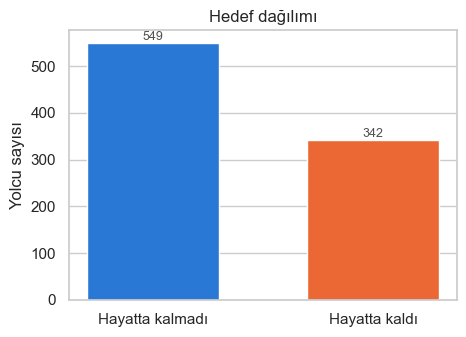

In [7]:
balance = train["Survived"].value_counts().to_frame("count")
balance["%"] = (balance["count"] / len(train) * 100).round(1)
display(balance.rename(index=SURVIVAL_LABELS))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar([SURVIVAL_LABELS[0], SURVIVAL_LABELS[1]], balance["count"].sort_index(),
       color=[SURVIVAL_COLORS[0], SURVIVAL_COLORS[1]], width=0.6)
label_bars(ax, fmt="{:.0f}")
ax.set(title="Hedef dağılımı", ylabel="Yolcu sayısı")
plt.show()

In [8]:
rates = pd.concat({
    col: train.groupby(col, observed=True)["Survived"].agg(passengers="size", survival_rate="mean")
    for col in ["Sex", "Pclass", "Embarked"]
})
rates.index.names = ["özellik", "değer"]
rates.round(3)

passengers  survival_rate
özellik  değer                            
Sex      male           577          0.189
         female         314          0.742
Pclass   1              216          0.630
         2              184          0.473
         3              491          0.242
Embarked C              168          0.554
         Q               77          0.390
         S              644          0.337

> **📖 Kadınlar ve üst sınıflar daha sık kurtuldu**
>
> - Verimizdeki yolcuların sadece **%38**'i kurtuldu. Herkese "öldü" deseydik bile %61.6 oranında haklı çıkardık.
> - **En büyük farkı cinsiyet yarattı:** kadınların %74'ü kurtuldu, erkeklerin sadece %19'u.
> - **Sınıf da önemliydi:** 1. sınıfın %63'ü, 2. sınıfın %47'si, 3. sınıfın %24'ü kurtuldu.
> - **Liman önemli görünüyor** (Cherbourg %55, Southampton %34), ama aşağıdaki teknik not bunun büyük ölçüde oradan *kimlerin* bindiğiyle ilgili olduğunu gösteriyor.

### 2.1 Çocuklar, sınıflar, ücretler ve aileler

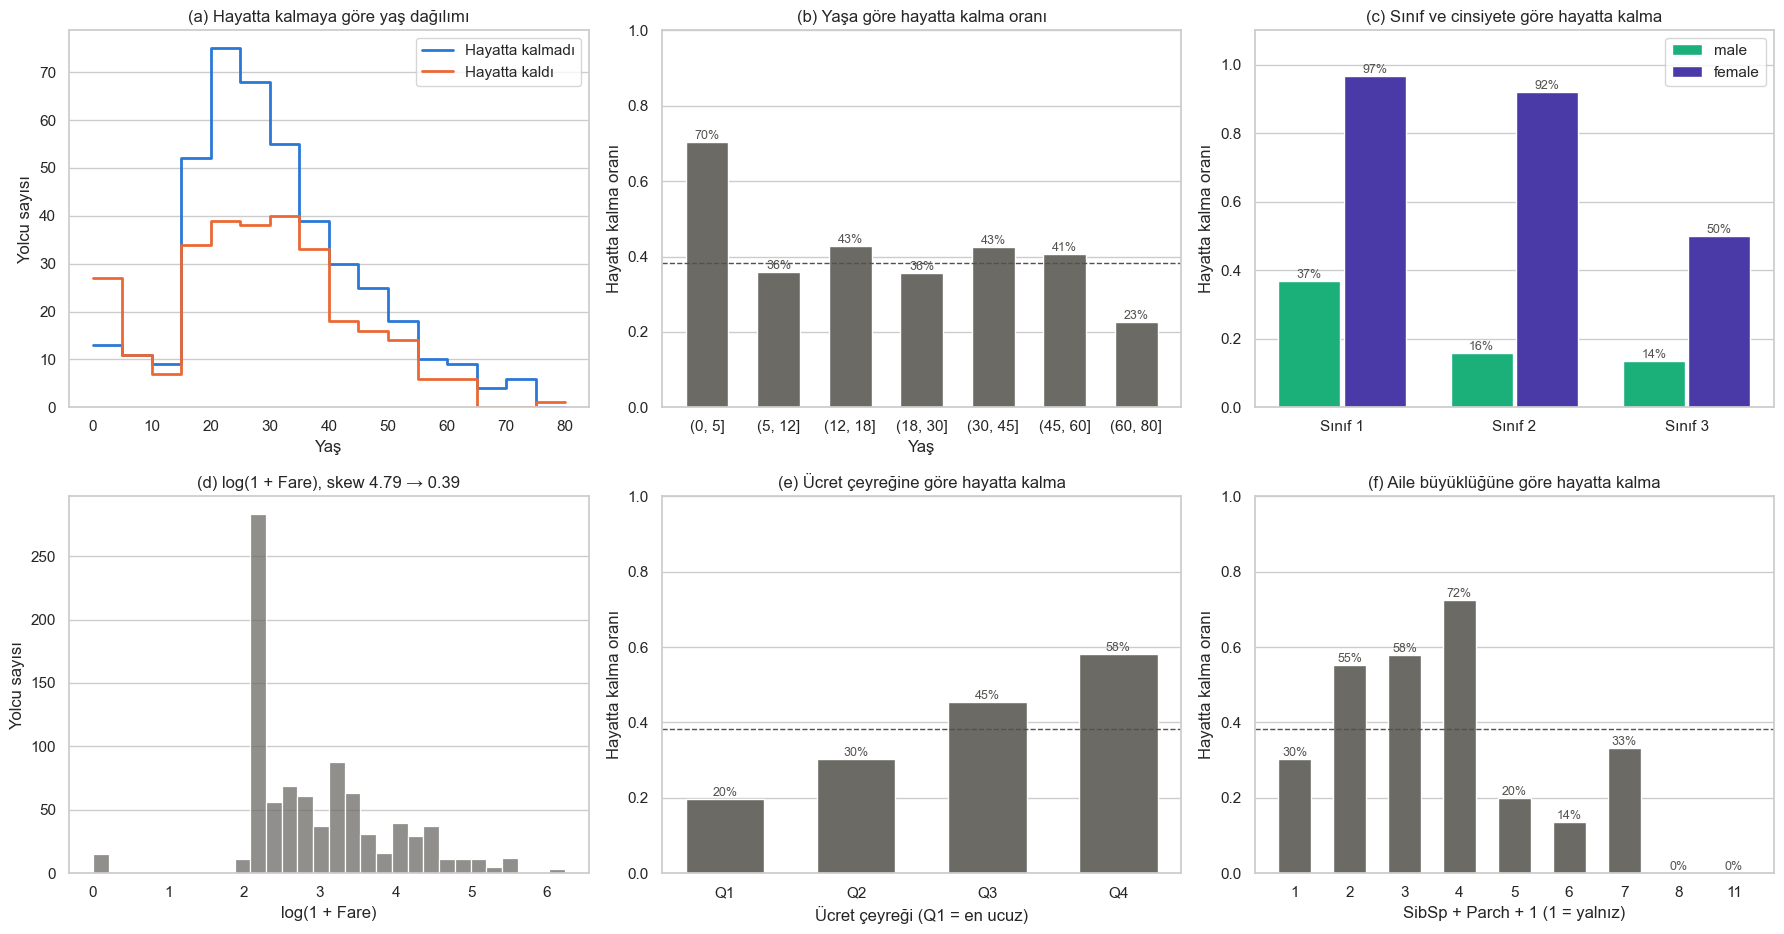

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5))

# (a) Age distribution by survival
ax = axes[0, 0]
for value in [0, 1]:
    sns.histplot(train.loc[train.Survived == value, "Age"].dropna(), bins=range(0, 85, 5), element="step",
                 fill=False, linewidth=2, color=SURVIVAL_COLORS[value], label=SURVIVAL_LABELS[value], ax=ax)
ax.set(title="(a) Hayatta kalmaya göre yaş dağılımı", xlabel="Yaş", ylabel="Yolcu sayısı")
ax.legend()

# (b) Survival rate by age band
rate_bar(axes[0, 1], train.groupby(pd.cut(train.Age, [0, 5, 12, 18, 30, 45, 60, 80]), observed=True)["Survived"].mean(),
         "(b) Yaşa göre hayatta kalma oranı", "Yaş")

# (c) Sex x Pclass
ax = axes[0, 2]
sex_class = train.groupby(["Pclass", "Sex"], observed=True)["Survived"].mean().unstack()
x, width = np.arange(3), 0.36
for i, sex in enumerate(["male", "female"]):
    ax.bar(x + (i - 0.5) * (width + 0.02), sex_class[sex], width=width, color=SEX_COLORS[sex], label=sex)
label_bars(ax)
ax.set_xticks(x, [f"Sınıf {c}" for c in sex_class.index])
ax.set(ylim=(0, 1.1), title="(c) Sınıf ve cinsiyete göre hayatta kalma", ylabel=RATE_LABEL)
ax.legend()

# (d) log(1 + Fare)
ax = axes[1, 0]
sns.histplot(np.log1p(train.Fare), bins=30, color=NEUTRAL, ax=ax)
ax.set(title=f"(d) log(1 + Fare), skew {train.Fare.skew():.2f} → {np.log1p(train.Fare).skew():.2f}",
       xlabel="log(1 + Fare)", ylabel="Yolcu sayısı")

# (e) Survival rate by fare quartile
rate_bar(axes[1, 1], train.groupby(pd.qcut(train.Fare, 4, labels=["Q1", "Q2", "Q3", "Q4"]), observed=True)["Survived"].mean(),
         "(e) Ücret çeyreğine göre hayatta kalma", "Ücret çeyreği (Q1 = en ucuz)")

# (f) Survival rate by family size
family_size = train.SibSp + train.Parch + 1
rate_bar(axes[1, 2], train.groupby(family_size)["Survived"].mean(), "(f) Aile büyüklüğüne göre hayatta kalma", "SibSp + Parch + 1 (1 = yalnız)")

plt.tight_layout()
plt.show()

In [10]:
age_group = np.select([train.Age.isna(), train.Age <= 12], ["yaş bilinmiyor", "çocuk (<=12)"], "yetişkin (>12)")
display(train.groupby([train.Sex, age_group], observed=True)["Survived"].agg(passengers="size", survival_rate="mean").round(3))

train.groupby(family_size)["Survived"].agg(passengers="size", survival_rate="mean").round(3).T

passengers  survival_rate
Sex                                             
male   yaş bilinmiyor         124          0.129
       yetişkin (>12)         416          0.173
       çocuk (<=12)            37          0.568
female yaş bilinmiyor          53          0.679
       yetişkin (>12)         229          0.777
       çocuk (<=12)            32          0.594

,1,2,3,4,5,6,7,8,11
passengers,537.000,161.000,102.000,29.000,15.0,22.000,12.000,6.0,7.0
survival_rate,0.304,0.553,0.578,0.724,0.2,0.136,0.333,0.0,0.0


> **📖 Kadınlar ve çocuklar daha sık kurtuldu, ama hepsi değil**
>
> - **(a, b) Çocuklar:** küçük çocukların (0 ile 5 yaş) %70'i kurtuldu, 60 yaş üstündekilerin ise sadece %23'ü. Tablo çocuk avantajının **erkek çocuklar için** geçerli olduğunu gösteriyor: erkek çocuklar %57, yetişkin erkekler %17. Kız çocuklar (%59) yetişkin kadınlardan (%78) daha iyi değildi.
> - **(c) Sınıf örüntüyü değiştirdi:** 1. ve 2. sınıf kadınlar **%97 ve %92** kurtuldu, 3. sınıfta sadece **%50**. Erkekler: 1. sınıfta %37, sonra %16 ve %14. 3. sınıf bir kadın bile 1. sınıf bir erkekten daha sık kurtuldu. **En büyük fark cinsiyette, sınıf bu farkın büyüklüğünü değiştiriyor.**
> - **(d, e) Para:** kurtulma oranı ücretle birlikte düzenli arttı; en ucuz çeyrekte **%20**, en pahalıda **%58**.
> - **(f) Aileler:** yalnız olanlar %30, 2 ile 4 kişilik aileler **%55 ile %72**, 5 ve daha kalabalık aileler en fazla %33 kurtuldu. Verimizde 8 ve 11 kişilik ailelerden kimse kurtulmadı.
> - **Yaşı bilinmeyen** yolcular daha az kurtuldu. Bölüm 3 bu ipucunun peşine düşüyor.

### 2.2 İsimlerin anlattıkları

Her isim `Soyad, Unvan. Adlar` kalıbında. Unvan cinsiyetten fazlasını söylüyor: **Master** erkek çocuklar için kullanılıyordu. Gruplama: `Mlle` ve `Ms` → `Miss`, `Mme` → `Mrs`; Mr, Mrs, Miss ve Master dışındaki her şey → `Rare`.

In [11]:
TITLE_PATTERN = r",\s*([^.]+)\."
raw_titles = pd.DataFrame({
    "train": train["Name"].str.extract(TITLE_PATTERN, expand=False).str.strip().value_counts(),
    "test": test["Name"].str.extract(TITLE_PATTERN, expand=False).str.strip().value_counts(),
}).fillna(0).astype(int)
raw_titles.sort_values("train", ascending=False).T

Name,Mr,Miss,Mrs,Master,Dr,Rev,Major,Col,Mlle,Sir,Ms,Capt,Mme,Lady,Jonkheer,Don,the Countess,Dona
train,517,182,125,40,7,6,2,2,2,1,1,1,1,1,1,1,1,0
test,240,78,72,21,1,2,0,2,0,0,1,0,0,0,0,0,0,1


In [12]:
TITLE_TYPE = pd.CategoricalDtype(["Mr", "Mrs", "Miss", "Master", "Rare"])
TITLE_MAP = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}


def extract_title(df):
    raw = df["Name"].str.extract(TITLE_PATTERN, expand=False).str.strip().replace(TITLE_MAP)
    return raw.where(raw.isin(TITLE_TYPE.categories), "Rare").astype(TITLE_TYPE)


train["Title"], test["Title"] = extract_title(train), extract_title(test)

pd.crosstab(train["Title"], train["Sex"]).join(
    train.groupby("Title", observed=True).agg(
        survival_rate=("Survived", "mean"),
        age_median=("Age", "median"),
        age_missing_train=("Age", lambda s: s.isna().sum()),
    )
).assign(test_passengers=test["Title"].value_counts(), age_missing_test=test.groupby("Title", observed=True)["Age"].apply(lambda s: s.isna().sum())).round(2)

,male,female,survival_rate,age_median,age_missing_train,test_passengers,age_missing_test
Title,,,,,,,
Mr,517,0,0.16,30.0,119,240,57
Mrs,0,126,0.79,35.0,17,72,10
Miss,0,185,0.70,21.0,36,79,15
Master,40,0,0.57,3.5,4,21,4
Rare,20,3,0.35,48.5,1,6,0


> **📖 Erkek çocuklar ve yetişkin erkekler aynı değildi**
>
> - Mr, Miss, Mrs ve Master yolcuların **%97**'sini kapsıyor. `Dona` sadece test'te geçiyor ve gruplama onu `Rare`'e gönderiyor.
> - **Unvana göre kurtulma:** Mrs %79, Miss %70, **Master %57**, Rare %35, **Mr %16**. Erkek çocuklar yetişkin erkeklerden üç kattan fazla sık kurtuldu; bu farkı tek başına `Sex` gösteremez.
> - **Unvana göre medyan yaş:** Master 3.5, Miss 21, Mr 30, Mrs 35, Rare 48.5. Bu, Bölüm 3'te eksik yaşları doldurmaya yardım edecek.

### 🔧 Teknik not: korelasyon

Kategorik sütunlar **geçici olarak** kodlanıyor: `Pclass` 1, 2, 3 olarak, `Sex` male 0 ve female 1 olarak, `Embarked` ise limanlar arasında sıra olmadığı için one-hot sütunlar olarak.

> **📘 Korelasyon nasıl okunur:** **işaret** yönü, **mutlak değer** |r| gücü gösterir. −0.338 olan `Pclass`, +0.257 olan `Fare`'den *daha güçlü* bir ilişkidir; bu yüzden özellikler |r|'ye göre sıralanır. Kabaca rehber: 0.1 altı yok denecek kadar zayıf, 0.1 ile 0.3 zayıf, 0.3 ile 0.5 orta, 0.5 ile 0.7 güçlü, 0.7 üstü çok güçlü.

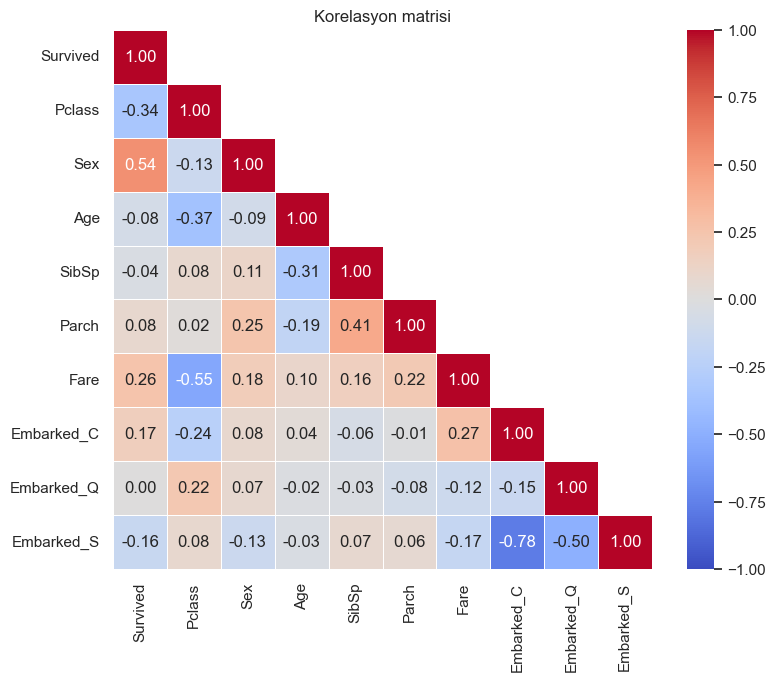

In [13]:
corr_df = pd.DataFrame({
    "Survived": train["Survived"],
    "Pclass": train["Pclass"].astype(int),
    "Sex": train["Sex"].cat.codes,  # male = 0, female = 1
    "Age": train["Age"],
    "SibSp": train["SibSp"],
    "Parch": train["Parch"],
    "Fare": train["Fare"],
}).join(pd.get_dummies(train["Embarked"], prefix="Embarked", dtype=int))
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.grid(False)
ax.set_title("Korelasyon matrisi")
plt.show()

In [14]:
target_corr = corr["Survived"].drop("Survived")
display(target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).round(3).to_frame("r_with_Survived"))

# Limana göre sınıf dağılımı (satır %), Embarked_C korelasyonunu açıklıyor
pd.crosstab(train["Embarked"], train["Pclass"], normalize="index").round(2)

,r_with_Survived
Sex,0.543
Pclass,-0.338
Fare,0.257
Embarked_C,0.168
Embarked_S,-0.156
Parch,0.082
Age,-0.077
SibSp,-0.035
Embarked_Q,0.004


Pclass,1,2,3
Embarked,,,
C,0.51,0.10,0.39
Q,0.03,0.04,0.94
S,0.20,0.25,0.55


> - **Kurtulma ile:** `Sex` **+0.54** (güçlü), `Pclass` **−0.34** (orta), `Fare` **+0.26**, `Embarked_C` +0.17. `Age`, `SibSp` ve `Parch` |0.1|'in altında; ama 2.1 bölümü önemli olduklarını gösterdi: Pearson sadece **düz çizgi** şeklindeki ilişkileri görür.
> - **Özellikler arası:** `Pclass` ile `Fare` **−0.55** (kısmen aynı bilgi), `SibSp` ile `Parch` **+0.41** (ikisi de aile üyelerini sayıyor), `Pclass` ile `Age` −0.37 (1. sınıf yolcuları daha yaşlıydı).
> - −0.78 olan `Embarked_C` ile `Embarked_S` ilişkisi **yapay**: aynı değişkenin one-hot sütunları birbirini dışlar.
> - **Liman hikâyesi aslında bir sınıf hikâyesi:** Cherbourg yolcularının %51'i 1. sınıftaydı, Queenstown yolcularının ise sadece %3'ü.
> - Gerçek hiçbir çift |0.8|'i geçmiyor, yani ciddi bir çoklu doğrusal bağlantı yok.

## Bölüm 3: Kimin Kayıtları Eksik?

Bazı yolcuların kayıtları eksiksiz; bazılarının ise yaşı bile yok. **Kimin kayıtları eksik ve bunun bir önemi var mı?**

In [15]:
age_unknown = train["Age"].isna()
travel = np.where(train["SibSp"] + train["Parch"] == 0, "yalnız", "aileyle")
pd.concat({
    "Embarked": age_unknown.groupby(train["Embarked"], observed=True).mean(),
    "Pclass": age_unknown.groupby(train["Pclass"], observed=True).mean(),
    "Seyahat": age_unknown.groupby(travel).mean(),
    "Sex": age_unknown.groupby(train["Sex"], observed=True).mean(),
}).mul(100).round(1).to_frame("% yaşı bilinmeyen")

% yaşı bilinmeyen
Embarked C                     22.6
         Q                     63.6
         S                     14.0
Pclass   1                     13.9
         2                      6.0
         3                     27.7
Seyahat  aileyle               12.4
         yalnız                24.8
Sex      male                  21.5
         female                16.9

> **📖 Eksik yaşlar Queenstown'da toplanıyor**
>
> - **Queenstown yolcularının üçte ikisinin yaşı kayıtlı değil (%64)**; bu oran Cherbourg'da %23, Southampton'da %14. Queenstown yolcularının %94'ü 3. sınıfta seyahat ediyordu (Bölüm 2, teknik not).
> - Yaş ayrıca **3. sınıfta** (%28) ve **yalnız seyahat edenlerde** (aileyle %12'ye karşı %25) daha sık eksik.
> - Veri bu yaşların *neden* eksik olduğunu **söylemiyor**. Gösterdiği şey eksik değerlerin **rastgele olmadığı**; yani "yaş bilinmiyor" bilgisinin kendisi saklanmaya değer.

### 3.1 Boşlukları doldurmak

**Kural:** her doldurma değeri **sadece train'den** öğrenilir ve iki dosyaya da uygulanır. Orijinal sütunlar `train_before` ve `test_before` içinde saklanır.

| Sütun | Nasıl dolduruluyor | Neden |
|---|---|---|
| `Age` | yolcunun **unvanına** ait medyan yaş | yaş unvana göre çok farklı |
| `Embarked` | train'deki en sık liman | ücret kanıtları birbiriyle çelişiyor |
| `Fare` (test) | **3. sınıf, Southampton** medyan ücreti | yolcunun sınıfı ve limanıyla eşleşiyor |

,count,mean,std,min,25%,50%,75%,max
before,714.0,29.70,14.53,0.42,20.12,28.0,38.0,80.0
after,891.0,29.39,13.27,0.42,21.00,30.0,35.0,80.0


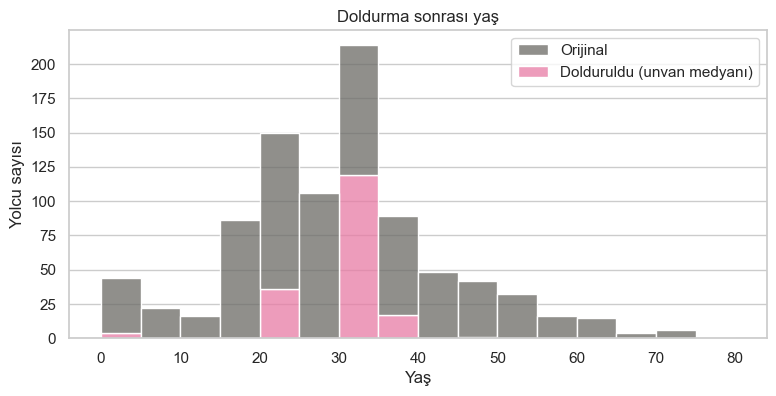

In [16]:
train_before, test_before = train[["Age", "Embarked", "Fare"]].copy(), test[["Age", "Embarked", "Fare"]].copy()

# Age
AGE_BY_TITLE = train.groupby("Title", observed=True)["Age"].median()


def fill_age(df):
    df = df.copy()
    df["Age"] = df["Age"].fillna(df["Title"].map(AGE_BY_TITLE).astype(float))
    return df


train, test = fill_age(train), fill_age(test)
display(pd.DataFrame({"before": train_before["Age"].describe(), "after": train["Age"].describe()}).round(2).T)

age_source = np.where(train_before["Age"].isna(), "Dolduruldu (unvan medyanı)", "Orijinal")
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(x=train["Age"], hue=age_source, hue_order=["Orijinal", "Dolduruldu (unvan medyanı)"], multiple="stack",
             bins=range(0, 85, 5), palette={"Orijinal": NEUTRAL, "Dolduruldu (unvan medyanı)": "#e87ba4"}, ax=ax)
ax.set(title="Doldurma sonrası yaş", xlabel="Yaş", ylabel="Yolcu sayısı")
plt.show()

> **📖 Yaş**
>
> - Train'de 177, test'te 86 yaş dolduruldu: Mr 30, Mrs 35, Miss 21, **Master 3.5**, Rare 48.5. Yaşı bilinmeyen bir erkek çocuk artık 28 yerine bir çocuk yaşı alıyor.
> - **Dürüst yan etki:** 119 erkeğin yerleştirildiği **30** yaşında bir tepe ve daha dar bir yayılım (standart sapma 14.53 → 13.27). Medyanla doldurma her zaman bunu yapar. İlk versiyon için kabul edilebilir.

In [17]:
# Embarked
display(train.loc[train_before["Embarked"].isna(), ["Name", "Sex", "Pclass", "Ticket", "Fare", "Cabin"]])

first = train[train.Pclass == 1]
fare_by_port = pd.concat({
    "1. sınıf, tümü": first.groupby("Embarked", observed=True)["Fare"].describe()[["count", "25%", "50%", "75%"]],
    "1. sınıf, kadınlar": first[first.Sex == "female"].groupby("Embarked", observed=True)["Fare"].describe()[["count", "25%", "50%", "75%"]],
}, axis=1)
display(fare_by_port.round(2))

EMBARKED_FILL = train["Embarked"].mode()[0]


def fill_embarked(df):
    df = df.copy()
    df["Embarked"] = df["Embarked"].fillna(EMBARKED_FILL)
    return df


train, test = fill_embarked(train), fill_embarked(test)
print("Doldurma değeri (train'deki en sık liman):", EMBARKED_FILL)

,Name,Sex,Pclass,Ticket,Fare,Cabin
61,"Icard, Miss. Amelie",female,1,113572,80.0,B28
829,"Stone, Mrs. George Nelson (Martha Evelyn)",female,1,113572,80.0,B28


1. sınıf, tümü                       1. sınıf, kadınlar               \
                  count    25%    50%     75%              count   25%    50%   
Embarked                                                                        
C                  85.0  49.50  78.27  110.88               43.0  69.3  83.16   
Q                   2.0  90.00  90.00   90.00                1.0  90.0  90.00   
S                 127.0  29.25  52.00   83.48               48.0  53.1  79.65   

                  
             75%  
Embarked          
C         134.50  
Q          90.00  
S         139.61

Doldurma değeri (train'deki en sık liman): S


> **📖 Mrs Stone ve Miss Icard**
>
> - Limanı bilinmeyen iki yolcu **Mrs Martha Evelyn Stone** ve **Miss Amelie Icard**: 1. sınıf, aynı bilet, B28 kabini, ücret 80.
> - **Ücret karar veremiyor.** Tüm 1. sınıf yolcularıyla karşılaştırınca 80 Cherbourg'u gösteriyor (medyan 78.27'ye karşı 52.00). 1. sınıf kadınlarla karşılaştırınca Southampton'ı gösteriyor (79.65'e karşı 83.16). 80, iki limanın da orta yarısının içinde.
> - Kanıtlar çelişkili olduğu için standart yöntem kullanıldı: **en sık liman, Southampton** (train'in %72'si).
> - Veri dışından, Encyclopedia Titanica ([Martha Stone](https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html), [Amelie Icard](https://www.encyclopedia-titanica.org/titanic-survivor/amelia-icard.html)) Miss Icard'ın Mrs Stone'un hizmetçisi olarak seyahat ettiğini, ikisinin de **Southampton'dan bindiğini** ve 6 numaralı filikayla kurtarıldığını kaydediyor.

In [18]:
# Fare (test)
display(test.loc[test_before["Fare"].isna(), ["Name", "Age", "Pclass", "SibSp", "Parch", "Embarked"]])

FARE_FILL = train.loc[(train.Pclass == 3) & (train.Embarked == "S"), "Fare"].median()


def fill_fare(df):
    df = df.copy()
    df["Fare"] = df["Fare"].fillna(FARE_FILL)
    return df


train, test = fill_fare(train), fill_fare(test)
print("Doldurma değeri (train, 3. sınıf ve Southampton):", FARE_FILL)

# Kalan kayıp değerler
pd.DataFrame({"train_missing": train.isnull().sum(), "test_missing": test.isnull().sum()}).query("train_missing > 0 or test_missing > 0")

,Name,Age,Pclass,SibSp,Parch,Embarked
152,"Storey, Mr. Thomas",60.5,3,0,0,S


Doldurma değeri (train, 3. sınıf ve Southampton): 8.05


,train_missing,test_missing
Cabin,687,327.0


> **📖 Mr Storey'nin bileti**
>
> - Ücreti bilinmeyen tek test yolcusu **Mr Thomas Storey**, 60 yaşında, **Southampton'dan 3. sınıfta yalnız** seyahat ediyordu. Bu grubun medyan ücreti olan **8.05**'i alıyor.
> - **Sadece `Cabin` eksik kaldı** (train'de 687, test'te 327). Doldurulmuyor; Bölüm 4 onu bir ipucuna dönüştürüyor.

## Bölüm 4: Bir Model Bu Hikâyeyi Öğrenebilir mi?

Hikâyeyi artık biliyoruz. Soru, bir makinenin bunu sadece kayıtlardan öğrenip cevabı saklı olan 418 yolcunun kaderini tahmin edip edemeyeceği.

### 4.1 Modele verdiğimiz ipuçları

| Yeni ipucu | Nasıl | Değerler |
|---|---|---|
| `GroupSize` | **aile büyüklüğü** (`SibSp + Parch + 1`) ile **bilet grubu** (aynı bileti paylaşan yolcular) arasından büyük olanı | Alone (1), Small (2 ile 4), Large (5 ve üstü) |
| `CabinShare` | aynı kabini paylaşan yolcu sayısı | NoCabin, Single (1), Shared (2 ve üstü) |
| `AgeMissing` | `Age` başlangıçta bilinmiyor muydu? | 0 / 1 |

Bilet ve kabin grupları **train ve test birlikte** sayılıyor, çünkü bir grup iki dosyaya bölünmüş olabilir. Sadece bilet ve kabin değerleri kullanılıyor, saklı cevaplar asla; yani sızıntı yok.

In [19]:
TICKET_COUNTS = pd.concat([train["Ticket"], test["Ticket"]]).value_counts()
CABIN_COUNTS = pd.concat([train["Cabin"], test["Cabin"]]).dropna().value_counts()
GROUP_TYPE = pd.CategoricalDtype(["Alone", "Small", "Large"], ordered=True)
CABIN_SHARE_TYPE = pd.CategoricalDtype(["NoCabin", "Single", "Shared"], ordered=True)


def add_features(df, df_before):
    df = df.copy()
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["TicketGroup"] = df["Ticket"].map(TICKET_COUNTS).astype(int)
    group = np.maximum(df["FamilySize"], df["TicketGroup"])
    df["GroupSize"] = pd.cut(group, [0, 1, 4, np.inf], labels=GROUP_TYPE.categories).astype(GROUP_TYPE)
    cabin_share = df["Cabin"].map(CABIN_COUNTS).fillna(0)
    df["CabinShare"] = pd.cut(cabin_share, [-1, 0, 1, np.inf], labels=CABIN_SHARE_TYPE.categories).astype(CABIN_SHARE_TYPE)
    df["AgeMissing"] = df_before["Age"].isna().astype(int)
    return df


train, test = add_features(train, train_before), add_features(test, test_before)

for col in ["GroupSize", "CabinShare", "AgeMissing"]:
    summary = train.groupby(col, observed=True)["Survived"].agg(train_n="size", survival_rate="mean")
    summary["test_n"] = test[col].value_counts()
    display(summary.round(3))

,train_n,survival_rate,test_n
GroupSize,,,
Alone,448,0.270,215
Small,356,0.553,164
Large,87,0.276,39


,train_n,survival_rate,test_n
CabinShare,,,
NoCabin,687,0.300,327
Single,75,0.520,32
Shared,129,0.752,59


,train_n,survival_rate,test_n
AgeMissing,,,
0,714,0.406,332
1,177,0.294,86


In [20]:
# Bilet grubu ne katıyor? Gemide ailesi olmayan yolcular, GroupSize'a göre
family_group = pd.cut(train["FamilySize"], [0, 1, 4, np.inf], labels=GROUP_TYPE.categories)
display(pd.crosstab(family_group, train["GroupSize"], rownames=["FamilySize"], colnames=["GroupSize"]))

alone_by_family = train[train["FamilySize"] == 1]
display(alone_by_family.groupby("GroupSize", observed=True)["Survived"].agg(passengers="size", survival_rate="mean").round(3))

# Limana göre AgeMissing
train.groupby(["Embarked", "AgeMissing"], observed=True)["Survived"].agg(passengers="size", survival_rate="mean").round(2).unstack()

GroupSize,Alone,Small,Large
FamilySize,,,
Alone,448,75,14
Small,0,281,11
Large,0,0,62


,passengers,survival_rate
GroupSize,,
Alone,448,0.270
Small,75,0.440
Large,14,0.643


passengers     survival_rate      
AgeMissing          0   1             0     1
Embarked                                     
C                 130  38          0.61  0.37
Q                  28  49          0.29  0.45
S                 556  90          0.37  0.18

> **📖 Gizli gruplar ve bilinmeyen yaşlar**
>
> - **GroupSize:** Alone %27, Small **%55**, Large %28.
> - **Bilet gizli grupları buldu:** gemide ailesi olmayan 89 yolcu bileti başka yolcularla paylaşıyordu. Bunlar **%47** kurtuldu, gerçekten yalnız olanlar sadece **%27**. Tek başına aile büyüklüğü onları kaçırırdı; Bölüm 3'teki Mrs Stone ve Miss Icard böyle bir çift.
> - **CabinShare:** NoCabin %30, Single %52, Shared **%75**.
> - **AgeMissing limana göre yön değiştiriyor:** Cherbourg ve Southampton'da bilinmeyen yaş daha düşük kurtulma demekti, **Queenstown'da tersi** (%29'a karşı %45).
> - Her kategori hem train'de hem test'te var.

Tüm orijinal sütunlar veride kalıyor. Model sadece `FEATURES` listesindeki sütunları alıyor.

In [21]:
TARGET = "Survived"
FEATURES = ["Pclass", "Sex", "Age", "Fare", "Embarked", "Title", "GroupSize", "CabinShare", "AgeMissing"]

pd.DataFrame({
    "dtype": train[FEATURES].dtypes.astype(str),
    "train_missing": train[FEATURES].isnull().sum(),
    "test_missing": test[FEATURES].isnull().sum(),
    "n_unique": train[FEATURES].nunique(),
})

,dtype,train_missing,test_missing,n_unique
Pclass,category,0,0,3
Sex,category,0,0,2
Age,float64,0,0,90
Fare,float64,0,0,248
Embarked,category,0,0,3
Title,category,0,0,5
GroupSize,category,0,0,3
CabinShare,category,0,0,3
AgeMissing,int64,0,0,2


In [22]:
train[FEATURES + [TARGET]].head()

,Pclass,Sex,Age,Fare,Embarked,Title,GroupSize,CabinShare,AgeMissing,Survived
0,3,male,22.0,7.2500,S,Mr,Small,NoCabin,0,0
1,1,female,38.0,71.2833,C,Mrs,Small,Shared,0,1
2,3,female,26.0,7.9250,S,Miss,Alone,NoCabin,0,1
3,1,female,35.0,53.1000,S,Mrs,Small,Shared,0,1
4,3,male,35.0,8.0500,S,Mr,Alone,NoCabin,0,0


> **9 ipucu**, train'de de test'te de eksik değer yok, iki dosyada tipler aynı.

### 4.2 Sekiz model yarışıyor

Sekiz model hikâyeyi öğrenmeye çalışıyor. Her biri 891 yolcunun **15 farklı bölmesinde** test ediliyor (5 parça, 3 tekrar): 4/5'inde öğreniyor, hiç görmediği 1/5'inde yargılanıyor. Tüm modeller **aynı 15 bölmeyi** alıyor, yani karşılaştırma adil.

| Model | Tek cümlelik fikri |
|---|---|
| Logistic Regression | bir **puan kartı**: her ipucu puan ekler ya da düşürür |
| SVM | kurtulanlarla ölenler arasına **en geniş koridoru** çizer |
| KNN | "bana **komşunu** söyle": en benzer 5 yolcuyu kopyalar |
| Random Forest | **kalabalığın bilgeliği**: yüzlerce ağaç oy verir |
| Gradient Boosting | ağaçlar arka arkaya kurulur, her biri **öncekinin hatalarını düzeltir** |
| XGBoost | ek düzenleme ve hız eklenmiş Gradient Boosting |

Doğrusal ve mesafe tabanlı modeller ölçeklenmiş sayılar ve one-hot sütunlar alıyor; ağaç modeller ham sayılar ve sıra kodları alıyor. Logistic Regression ham `Fare` ile, `LogFare` ile ve `LogFare` artı `Sex × Pclass` ile deneniyor.

In [23]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

SEED = 42


def add_model_columns(df):
    df = df.copy()
    df["LogFare"] = np.log1p(df["Fare"])
    df["SexPclass"] = (df["Sex"].astype(str) + "_" + df["Pclass"].astype(str)).astype("category")
    return df


train, test = add_model_columns(train), add_model_columns(test)
y = train[TARGET]

CAT = ["Pclass", "Sex", "Embarked", "Title", "GroupSize", "CabinShare"]
NUM_RAW = ["Age", "Fare", "AgeMissing"]
NUM_LOG = ["Age", "LogFare", "AgeMissing"]


def linear_prep(num, cat):
    return ColumnTransformer([("num", StandardScaler(), num), ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])


def tree_prep(num, cat):
    categories = [list(train[c].cat.categories) for c in cat]
    return ColumnTransformer([("num", "passthrough", num), ("cat", OrdinalEncoder(categories=categories), cat)])


MODELS = {
    "Logistic Regression": (linear_prep(NUM_RAW, CAT), LogisticRegression(max_iter=1000), NUM_RAW + CAT),
    "Logistic Regression + LogFare": (linear_prep(NUM_LOG, CAT), LogisticRegression(max_iter=1000), NUM_LOG + CAT),
    "Logistic Regression + LogFare + Sex×Pclass": (linear_prep(NUM_LOG, CAT + ["SexPclass"]), LogisticRegression(max_iter=1000), NUM_LOG + CAT + ["SexPclass"]),
    "SVM (RBF)": (linear_prep(NUM_LOG, CAT), SVC(random_state=SEED), NUM_LOG + CAT),
    "KNN": (linear_prep(NUM_LOG, CAT), KNeighborsClassifier(), NUM_LOG + CAT),
    "Random Forest": (tree_prep(NUM_RAW, CAT), RandomForestClassifier(random_state=SEED), NUM_RAW + CAT),
    "Gradient Boosting": (tree_prep(NUM_RAW, CAT), GradientBoostingClassifier(random_state=SEED), NUM_RAW + CAT),
    "XGBoost": (tree_prep(NUM_RAW, CAT), XGBClassifier(random_state=SEED, n_jobs=1), NUM_RAW + CAT),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
FOLDS = list(cv.split(train, y))

In [24]:
fold_scores, rows = {}, []

# Baselines evaluated on the same folds
fold_scores["Referans: herkes ölür"] = np.array([(y.iloc[val] == 0).mean() for _, val in FOLDS])
fold_scores["Referans: kadınlar yaşar"] = np.array([((train["Sex"].iloc[val] == "female").astype(int) == y.iloc[val]).mean() for _, val in FOLDS])
for name in fold_scores:
    rows.append({"model": name, "cv_mean": fold_scores[name].mean(), "cv_std": fold_scores[name].std(),
                 "train_mean": np.nan, "overfit_gap": np.nan, "seconds": np.nan})

for name, (prep, model, cols) in MODELS.items():
    start = time.time()
    result = cross_validate(make_pipeline(prep, model), train[cols], y, cv=FOLDS, return_train_score=True)
    fold_scores[name] = result["test_score"]
    rows.append({
        "model": name,
        "cv_mean": result["test_score"].mean(),
        "cv_std": result["test_score"].std(),
        "train_mean": result["train_score"].mean(),
        "overfit_gap": result["train_score"].mean() - result["test_score"].mean(),
        "seconds": time.time() - start,
    })

benchmark = pd.DataFrame(rows).set_index("model").sort_values("cv_mean", ascending=False)
benchmark.round(4)

,cv_mean,cv_std,train_mean,overfit_gap,seconds
model,,,,,
Gradient Boosting,0.8369,0.0224,0.9096,0.0727,1.1987
Logistic Regression + LogFare + Sex×Pclass,0.8309,0.0202,0.8459,0.0150,0.1931
Logistic Regression + LogFare,0.8305,0.0216,0.8404,0.0099,0.1805
Logistic Regression,0.8275,0.0190,0.8387,0.0112,0.2643
SVM (RBF),0.8238,0.0220,0.8519,0.0281,0.5070
Random Forest,0.8227,0.0132,0.9890,0.1663,1.5601
KNN,0.8126,0.0147,0.8594,0.0469,0.5936
XGBoost,0.8118,0.0216,0.9788,0.1669,0.3918
Referans: kadınlar yaşar,0.7867,0.0209,NaN,NaN,NaN


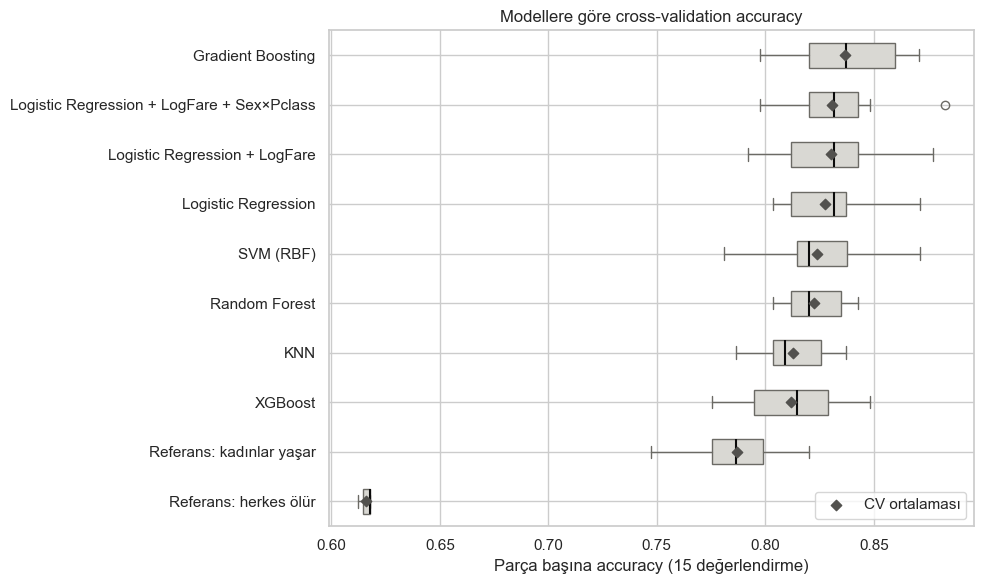

In [25]:
order = benchmark.index.tolist()
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([fold_scores[m] for m in order][::-1], vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#d9d8d3", color=NEUTRAL), medianprops=dict(color="#0b0b0b", linewidth=1.5),
           whiskerprops=dict(color=NEUTRAL), capprops=dict(color=NEUTRAL), flierprops=dict(markeredgecolor=NEUTRAL))
ax.scatter([fold_scores[m].mean() for m in order][::-1], range(1, len(order) + 1), color=INK, marker="D", zorder=3, s=28, label="CV ortalaması")
ax.set_yticks(range(1, len(order) + 1), order[::-1])
ax.grid(axis="x", visible=True)
ax.set(xlabel="Parça başına accuracy (15 değerlendirme)", title="Modellere göre cross-validation accuracy")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
# Eşleştirilmiş karşılaştırma: en iyi model ile diğer her model, aynı 15 parçada
best = benchmark.drop(index=[i for i in benchmark.index if i in ("Referans: herkes ölür", "Referans: kadınlar yaşar")]).index[0]
paired = pd.DataFrame({
    "mean_diff_vs_best": {m: (fold_scores[best] - fold_scores[m]).mean() for m in MODELS if m != best},
    "std_of_diff": {m: (fold_scores[best] - fold_scores[m]).std() for m in MODELS if m != best},
    "best_wins_of_15": {m: int((fold_scores[best] > fold_scores[m]).sum()) for m in MODELS if m != best},
    "ties": {m: int((fold_scores[best] == fold_scores[m]).sum()) for m in MODELS if m != best},
}).sort_values("mean_diff_vs_best")
print("En iyi model:", best)
paired.round(4)

En iyi model: Gradient Boosting


,mean_diff_vs_best,std_of_diff,best_wins_of_15,ties
Logistic Regression + LogFare + Sex×Pclass,0.0060,0.0147,7,5
Logistic Regression + LogFare,0.0064,0.0143,9,2
Logistic Regression,0.0094,0.0171,11,0
SVM (RBF),0.0131,0.0179,12,1
Random Forest,0.0142,0.0216,9,2
KNN,0.0243,0.0193,13,1
XGBoost,0.0251,0.0117,14,0


> **📖 Yarış berabere bitiyor**
>
> - **Her model iki referans skoru da geçiyor.** En iyisi "kadınlar yaşar" kuralının (%78.7) yaklaşık 5 puan üstünde.
> - **İlk dört model pratikte berabere:** Gradient Boosting **%83.7**, Logistic Regression **%83.1**. Aradaki fark bölmeler arasındaki değişimden (yaklaşık ±2 puan) çok küçük ve Gradient Boosting 15 bölmenin sadece 7'sini kazanıyor.
> - **Bazı modeller ezberliyor:** Random Forest ve XGBoost öğrendikleri yolcularda %98 ile %99'a çıkıyor, yeni yolcularda ise sadece %81 ile %82. Logistic Regression 1 puan içinde kalıyor.
> - Aşağıdaki teknik notlar bu farkların gerçek olup olmadığını kontrol ediyor.

### 🔧 Teknik not A: farklar gerçek mi?

Her model **Logistic Regression + LogFare** ile karşılaştırılıyor.

| Test | Soru | Normallik varsayar mı | Örtüşen parçaları hesaba katar mı |
|---|---|---|---|
| Shapiro-Wilk | Parça farkları normal mi? | geçerli değil | ❌ |
| Wilcoxon işaretli sıra | Medyan fark sıfır mı? | ❌ | ❌ |
| **Düzeltilmiş tekrarlı örnekleme t-testi** | Ortalama fark sıfır mı? | ✅ | ✅ |
| **Bayesçi korelasyonlu t-testi** | Fark *pratikte* önemli mi (ROPE ±1 puan)? | ✅ | ✅ |
| **McNemar** | Modeller aynı yolcularda farklı hatalar mı yapıyor? | ❌ | ✅ (her seferinde tek bölme) |
| **Friedman + Nemenyi** | Tüm modeller grup olarak eşit mi? | ❌ | ❌ |

**Neden düzeltme?** 5-fold CV'de iki eğitim seti satırlarının %75'ini paylaşır; bu yüzden 15 skor **bağımsız değildir** ve standart testler olmayan farklar bulur. Nadeau ve Bengio düzeltmesi varyansı büyütür: $t = \bar d \,/\, \sqrt{(1/n + n_{test}/n_{train})\, \hat\sigma^2}$, burada $n = 15$ ve $n_{test}/n_{train} = 0.25$.

> **p nasıl okunur:** p, **gerçekte hiç fark yokken** bu kadar büyük bir fark görme ihtimalidir. **Küçük p (0.05 altı): şaşırtıcı, fark anlamlı.** Büyük p: yeterli kanıt yok, ama bu eşitliğin kanıtı *değil*. Mahkeme gibi: "suçsuz" demek "masum" demek değildir.

In [27]:
from scipy import stats

REFERENCE = "Logistic Regression + LogFare"
N_EVAL = len(FOLDS)
TEST_TRAIN_RATIO = 1 / (5 - 1)
ROPE = 0.01
challengers = [m for m in MODELS if m != REFERENCE]


def diffs(model):
    return fold_scores[model] - fold_scores[REFERENCE]


# 1. Assumption check
assumptions = pd.DataFrame({
    m: {
        "shapiro_W": stats.shapiro(diffs(m)).statistic,
        "shapiro_p": stats.shapiro(diffs(m)).pvalue,
        "skew": stats.skew(diffs(m)),
        "zero_diffs": int((np.abs(diffs(m)) < 1e-9).sum()),
        "wilcoxon_p": stats.wilcoxon(diffs(m), zero_method="zsplit").pvalue,
        "naive_t_p": stats.ttest_1samp(diffs(m), 0).pvalue,
    } for m in challengers
}).T
display(assumptions.round(3))

# Shapiro, sadece 15 değerle açıkça normal olmayan veriyi ne sıklıkla yakalıyor? (her biri 2.000 simülasyon)
rng = np.random.default_rng(SEED)
alternatives = {"chi2(3)": lambda: rng.chisquare(3, N_EVAL), "t(3)": lambda: rng.standard_t(3, N_EVAL),
                "uniform": lambda: rng.uniform(size=N_EVAL)}
print("n=15'te Shapiro'nun yakalama oranı:", {name: round(np.mean([stats.shapiro(gen()).pvalue < 0.05 for _ in range(2000)]), 2)
                          for name, gen in alternatives.items()})

,shapiro_W,shapiro_p,skew,zero_diffs,wilcoxon_p,naive_t_p
Logistic Regression,0.914,0.159,0.347,5.0,0.130,0.150
Logistic Regression + LogFare + Sex×Pclass,0.949,0.511,-0.365,3.0,0.776,0.921
SVM (RBF),0.935,0.327,-0.406,3.0,0.172,0.108
KNN,0.971,0.868,0.138,2.0,0.006,0.003
Random Forest,0.974,0.917,0.171,1.0,0.181,0.203
Gradient Boosting,0.951,0.533,-0.120,2.0,0.111,0.118
XGBoost,0.956,0.623,-0.443,0.0,0.002,0.002


n=15'te Shapiro'nun yakalama oranı: {'chi2(3)': np.float64(0.5), 't(3)': np.float64(0.26), 'uniform': np.float64(0.12)}


> - **Shapiro-Wilk hiçbir modelde normalliği reddetmiyor** (p 0.16 ile 0.92 arasında) ve çarpıklık küçük.
> - Ama "reddedilmedi" "normal" demek değil: 15 değerle Shapiro açıkça normal olmayan veriyi sadece yaklaşık %12 ile %50 oranında yakalıyor.
> - Normallik yine de **teorik olarak makul**: her parçanın accuracy'si yaklaşık 178 doğru ya da yanlış sonucun ortalaması (merkezi limit teoremi).
> - **Normallik testine bakıp test seçmek önerilmez** (Rochon ve ark., 2012), bu yüzden testler tasarıma göre seçildi.
> - ⚠️ **Asıl büyük sorun bağımsızlık:** Wilcoxon KNN ve XGBoost için p = 0.006 ve 0.002 veriyor, *düzeltilmemiş* t-testiyle neredeyse aynı. Parametrik olmayan bir test örtüşen parçaları düzeltmez.

In [28]:
# 2. Corrected resampled t-test and 3. Bayesian correlated t-test
rows = []
for m in challengers:
    d = diffs(m)
    se = np.sqrt((1 / N_EVAL + TEST_TRAIN_RATIO) * d.var(ddof=1))
    t_stat = d.mean() / se
    posterior = stats.t(df=N_EVAL - 1, loc=d.mean(), scale=se)
    rows.append({
        "model": m,
        "diff_points": d.mean() * 100,
        "ci95_low": posterior.ppf(0.025) * 100,
        "ci95_high": posterior.ppf(0.975) * 100,
        "p_corrected": 2 * stats.t.sf(abs(t_stat), N_EVAL - 1),
        "p_naive": stats.ttest_1samp(d, 0).pvalue,
        "P_worse": posterior.cdf(-ROPE),
        "P_equivalent": posterior.cdf(ROPE) - posterior.cdf(-ROPE),
        "P_better": posterior.sf(ROPE),
    })
significance = pd.DataFrame(rows).set_index("model").sort_values("diff_points", ascending=False)
print("Referans:", REFERENCE, "| ROPE = ±1 puan")
significance.round(3)

Referans: Logistic Regression + LogFare | ROPE = ±1 puan


,diff_points,ci95_low,ci95_high,p_corrected,p_naive,P_worse,P_equivalent,P_better
model,,,,,,,,
Gradient Boosting,0.638,-1.151,2.426,0.457,0.118,0.035,0.630,0.335
Logistic Regression + LogFare + Sex×Pclass,0.039,-1.777,1.855,0.964,0.921,0.120,0.742,0.138
Logistic Regression,-0.299,-1.217,0.619,0.496,0.150,0.062,0.934,0.004
SVM (RBF),-0.672,-2.502,1.158,0.444,0.108,0.353,0.612,0.035
Random Forest,-0.784,-3.525,1.958,0.550,0.203,0.434,0.474,0.092
KNN,-1.794,-4.082,0.495,0.115,0.003,0.765,0.225,0.010
XGBoost,-1.868,-4.145,0.410,0.100,0.002,0.786,0.205,0.009


> - Düzeltmeden sonra **hiçbir fark anlamlı değil** (tüm p 0.05 üstünde). Gradient Boosting'in +0.64 puanının %95 aralığı yaklaşık [−1.2, +2.4] ve sıfırı içeriyor.
> - Düzeltme önemli: sıradan t-testi KNN ve XGBoost'u "anlamlı şekilde kötü" buluyor (p = 0.003 ve 0.002), düzeltilmiş test bulmuyor (p = 0.12 ve 0.10).
> - **Bayesçi bakış:** Gradient Boosting **%63 ihtimalle pratikte eşit**, %34 daha iyi, %3 daha kötü. `Sex × Pclass` (%74) ve ham `Fare` yerine `LogFare` (%93) pratikte eşit. KNN ve XGBoost yaklaşık %78 ihtimalle daha kötü.
> - 891 yolcuyla aralıklar yaklaşık ±2 puan genişliğinde: veri **1 puanlık farkları tespit edemiyor**.

In [29]:
# 4. McNemar: out-of-fold predictions, one 5-fold partition per repeat
from sklearn.model_selection import cross_val_predict


def oof_predictions(name, folds):
    prep, model, cols = MODELS[name]
    return cross_val_predict(make_pipeline(prep, model), train[cols], y, cv=folds)


mcnemar_rows = []
for rep in range(3):
    partition = FOLDS[rep * 5:(rep + 1) * 5]
    ref_correct = oof_predictions(REFERENCE, partition) == y
    for other in ["Gradient Boosting", "XGBoost"]:
        other_pred = oof_predictions(other, partition)
        other_correct = other_pred == y
        ref_only = int((ref_correct & ~other_correct).sum())
        other_only = int((~ref_correct & other_correct).sum())
        mcnemar_rows.append({
            "repeat": rep + 1, "model": other,
            "same_prediction_%": (ref_correct == other_correct).mean() * 100,
            "only_reference_right": ref_only, "only_other_right": other_only,
            "p_exact": stats.binomtest(min(ref_only, other_only), ref_only + other_only, 0.5).pvalue,
        })
display(pd.DataFrame(mcnemar_rows).set_index(["model", "repeat"]).round(3))

# 5. Friedman and Nemenyi over all models
score_matrix = pd.DataFrame({m: fold_scores[m] for m in MODELS})
chi2, p_friedman = stats.friedmanchisquare(*score_matrix.T.values)
avg_rank = score_matrix.rank(axis=1, ascending=False).mean().sort_values()
k = len(MODELS)
critical_difference = stats.studentized_range.ppf(0.95, k, np.inf) / np.sqrt(2) * np.sqrt(k * (k + 1) / (6 * N_EVAL))
print(f"Friedman chi2 = {chi2:.2f}, p = {p_friedman:.2g} | Nemenyi CD (alpha 0.05) = {critical_difference:.2f}")
pd.DataFrame({
    "avg_rank": avg_rank,
    "en_iyiden_farklı": avg_rank - avg_rank.iloc[0] > critical_difference,
    "referanstan_farklı": (avg_rank - avg_rank[REFERENCE]).abs() > critical_difference,
}).round(2)

,,same_prediction_%,only_reference_right,only_other_right,p_exact
model,repeat,,,,
Gradient Boosting,1,91.919,32,40,0.410
XGBoost,1,88.215,60,45,0.172
Gradient Boosting,2,92.705,32,33,1.000
XGBoost,2,88.552,61,41,0.059
Gradient Boosting,3,92.368,30,38,0.396
XGBoost,3,89.113,56,41,0.155


Friedman chi2 = 38.48, p = 2.5e-06 | Nemenyi CD (alpha 0.05) = 2.71


,avg_rank,en_iyiden_farklı,referanstan_farklı
Gradient Boosting,2.63,False,False
Logistic Regression + LogFare + Sex×Pclass,3.13,False,False
Logistic Regression + LogFare,3.60,False,False
Logistic Regression,4.37,False,False
Random Forest,4.40,False,False
SVM (RBF),4.77,False,False
KNN,6.50,True,True
XGBoost,6.60,True,True


> - **Logistic Regression ve Gradient Boosting yolcuların yaklaşık %92'sinde aynı cevabı veriyor.** Anlaşmadıkları yaklaşık 70 yolcuda hiçbiri anlamlı şekilde daha iyi değil (p 0.40 ile 1.00 arasında): pratikte **aynı kuralı** öğrenmişler.
> - XGBoost'a karşı Logistic Regression 3 tekrarın üçünde de önde, ama anlamlı değil (p 0.06 ile 0.17 arasında).
> - **Friedman:** modellerin hepsi eşit değil (p < 0.001). **Nemenyi:** Gradient Boosting ve iki Logistic Regression + LogFare varyantı KNN ve XGBoost'tan daha iyi sıralanıyor; ilk altı model birbirinden ayrılamıyor. ⚠️ Bu testler bağımsız bloklar varsayıyor, yani bu daha zayıf bir kanıt.
>
> **A notunun sonucu:** farklı varsayımlara sahip beş test aynı yerde buluşuyor: Gradient Boosting ile Logistic Regression + LogFare **istatistiksel olarak eşdeğer**. Eşitlik durumunda daha basit, yorumlanabilir ve daha az ayar gerektiren model tercih edilir (Cawley ve Talbot, 2010); bu, basit modellerin her zaman daha iyi genelleştiği iddiası değil (Domingos, 1999).
>
> **Kaynaklar:** Dietterich (1998) *Neural Computation* 10(7) · Nadeau ve Bengio (2003) *Machine Learning* 52(3) · Bouckaert ve Frank (2004) *PAKDD* · Demšar (2006) *JMLR* 7 · Varma ve Simon (2006) *BMC Bioinformatics* 7 · Cawley ve Talbot (2010) *JMLR* 11 · Rochon, Gondan ve Kieser (2012) *BMC Med. Res. Methodol.* 12 · Benavoli ve ark. (2017) *JMLR* 18 · Domingos (1999) *Data Min. Knowl. Discov.* 3(4)

### 🔧 Teknik not B: accuracy'den fazlası

| Metrik | Soru | Akılda kalsın |
|---|---|---|
| **Accuracy** | Tahminlerin ne kadarı doğru? | genel karne notu |
| **Precision** | "Kurtuldu" denen yolcuların kaçı gerçekten kurtuldu? | kurtulan listesi ne kadar temiz |
| **Recall** | Gerçekten kurtulanların kaçı bulundu? | kurtulan listesi ne kadar eksiksiz |
| **F1** | precision ve recall'un harmonik ortalaması | kurtulanları temiz ve eksiksiz bulmak |
| **ROC-AUC** | Rastgele bir kurtulana, rastgele bir ölenden daha yüksek olasılık veriliyor mu? | ayırt etme gücü: 0.5 yazı tura, 1.0 mükemmel |

In [30]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

METRICS = {"accuracy": accuracy_score, "f1": f1_score, "roc_auc": roc_auc_score,
           "precision": precision_score, "recall": recall_score}

metric_scores = {}
for name, (prep, model, cols) in MODELS.items():
    result = cross_validate(make_pipeline(prep, model), train[cols], y, cv=FOLDS, scoring=list(METRICS))
    metric_scores[name] = {m: result[f"test_{m}"] for m in METRICS}

# Aynı parçalarda referans kural (kesin 0/1 tahmin, bu yüzden ROC-AUC'si dengeli accuracy'ye eşit)
gender_pred = (train["Sex"] == "female").astype(int)
metric_scores["Referans: kadınlar yaşar"] = {
    m: np.array([fn(y.iloc[val], gender_pred.iloc[val]) for _, val in FOLDS]) for m, fn in METRICS.items()
}


def corrected_p(a, b):
    d = a - b
    se = np.sqrt((1 / N_EVAL + TEST_TRAIN_RATIO) * d.var(ddof=1))
    return 2 * stats.t.sf(abs(d.mean() / se), N_EVAL - 1)


multi = pd.DataFrame({
    name: {
        "accuracy": s["accuracy"].mean() * 100,
        "p_accuracy": np.nan if name == REFERENCE else corrected_p(s["accuracy"], metric_scores[REFERENCE]["accuracy"]),
        "f1": s["f1"].mean() * 100,
        "p_f1": np.nan if name == REFERENCE else corrected_p(s["f1"], metric_scores[REFERENCE]["f1"]),
        "roc_auc": s["roc_auc"].mean() * 100,
        "p_roc_auc": np.nan if name == REFERENCE else corrected_p(s["roc_auc"], metric_scores[REFERENCE]["roc_auc"]),
        "precision": s["precision"].mean() * 100,
        "recall": s["recall"].mean() * 100,
    } for name, s in metric_scores.items()
}).T.sort_values("accuracy", ascending=False)

n_tests = int(multi[["p_accuracy", "p_f1", "p_roc_auc"]].notna().sum().sum())
print(f"Referans: {REFERENCE} | test {n_tests} → p < 0.05'te beklenen yanlış pozitif ≈ {n_tests * 0.05:.1f}")
multi.round(3)

Referans: Logistic Regression + LogFare | test 24 → p < 0.05'te beklenen yanlış pozitif ≈ 1.2


,accuracy,p_accuracy,f1,p_f1,roc_auc,p_roc_auc,precision,recall
Gradient Boosting,83.688,0.457,77.626,0.767,87.884,0.261,81.827,74.085
Logistic Regression + LogFare + Sex×Pclass,83.089,0.964,76.535,0.604,87.242,0.460,81.806,72.039
Logistic Regression + LogFare,83.050,NaN,77.265,NaN,87.017,NaN,79.414,75.340
Logistic Regression,82.751,0.496,76.821,0.457,86.970,0.645,79.174,74.753
SVM (RBF),82.378,0.444,75.366,0.143,86.558,0.563,81.504,70.281
Random Forest,82.266,0.550,76.076,0.496,87.655,0.421,79.001,73.495
KNN,81.256,0.115,73.999,0.049,85.491,0.085,79.101,69.594
XGBoost,81.182,0.100,74.541,0.058,86.797,0.845,77.429,72.128
Referans: kadınlar yaşar,78.675,0.001,70.970,0.001,76.687,0.000,74.257,68.126


> - **Üç metrik de aynı yönde:** Gradient Boosting en üstte (accuracy 83.7, F1 77.6, ROC-AUC 87.9), ama referanstan hiçbir fark anlamlı değil (p 0.26 ile 0.77 arasında).
> - **Her model "kadınlar yaşar" kuralını açıkça geçiyor** (p ≤ 0.001). ROC-AUC yaklaşık 77'den yaklaşık 87'ye çıkıyor: ipuçları cinsiyetin ötesinde gerçek ayırt etme gücü katıyor.
> - **KNN F1: p = 0.049**, kâğıt üstünde anlamlı. 24 testte şans eseri yaklaşık 1 yanlış pozitif beklenir, bu yüzden sınırda sayıldı.
> - **Random Forest** accuracy'de 6. ama ROC-AUC'de 2. (87.7): yolcuları iyi sıralıyor ama 0.5 eşiği onları kötü kesiyor.
> - SVM ve KNN isabetli ama daha çok kurtulanı kaçırıyor (recall yaklaşık %70); Logistic Regression + LogFare daha dengeli (%79 precision, %75 recall).

### 🔧 Teknik not C: sızıntısız pipeline

Bölüm 3'te bazı doldurma değerleri **cross-validation'dan önce tüm train üzerinde** öğrenildi; yani her doğrulama parçası kendi doldurma değerinin hesabına katkı yaptı: küçük bir **sızıntı**. *Veriden öğrenen* her adım pipeline'a taşınıyor ve sadece eğitim parçalarında öğreniliyor.

| Adım | Veriden öğreniyor mu? | Sızıntı riski | Şimdi nerede |
|---|---|---|---|
| Tipler, `Title`, `AgeMissing` | hayır, satır satır | yok | dışarıda |
| `Age`, unvana göre medyandan | **evet** | ⚠️ | **pipeline** |
| `Embarked`, en sık limandan | **evet** | ⚠️ | **pipeline** |
| `Fare`, sınıf ve limana göre medyandan, ardından `LogFare` | **evet** | ⚠️ | **pipeline** |
| `GroupSize`, `CabinShare` | değerleri sayıyor, **cevap yok** | yok | dışarıda |
| Ölçekleme ve kodlama | evet | zaten içeride | pipeline |

In [31]:
from sklearn.base import BaseEstimator, TransformerMixin


class FoldImputer(BaseEstimator, TransformerMixin):
    """Doldurma değerlerini sadece eğitim parçalarında öğrenir: unvana göre Age, Embarked modu, sınıf ve limana göre Fare."""

    def fit(self, X, y=None):
        self.age_by_title_ = X.groupby("Title", observed=True)["Age"].median()
        self.age_overall_ = X["Age"].median()
        self.embarked_mode_ = X["Embarked"].mode()[0]
        self.fare_by_group_ = X.groupby(["Pclass", "Embarked"], observed=True)["Fare"].median()
        self.fare_overall_ = X["Fare"].median()
        return self

    def transform(self, X):
        X = X.copy()
        X["Age"] = X["Age"].fillna(X["Title"].map(self.age_by_title_).astype(float)).fillna(self.age_overall_)
        X["Embarked"] = X["Embarked"].fillna(self.embarked_mode_)
        group_fare = self.fare_by_group_.reindex(pd.MultiIndex.from_arrays([X["Pclass"], X["Embarked"]]))
        X["Fare"] = X["Fare"].fillna(pd.Series(group_fare.values, index=X.index)).fillna(self.fare_overall_)
        X["LogFare"] = np.log1p(X["Fare"])
        return X


# ORİJİNAL eksik değerleri geri yüklenmiş model girdisi; onları pipeline dolduruyor
IMPUTE_COLS = ["Title", "Pclass", "Embarked", "Age", "Fare", "LogFare"]
train_raw, test_raw = train.copy(), test.copy()
train_raw[["Age", "Embarked", "Fare"]] = train_before[["Age", "Embarked", "Fare"]]
test_raw[["Age", "Embarked", "Fare"]] = test_before[["Age", "Embarked", "Fare"]]
train_raw["LogFare"], test_raw["LogFare"] = np.nan, np.nan

# Kontrol: tüm train'de eğitilince, test'te bölüm 9'daki değerleri aynen üretmeli
check_imputer = FoldImputer().fit(train_raw)
filled_test = check_imputer.transform(test_raw)
print("Doldurmadan sonra test'te kalan eksik değer:", filled_test[["Age", "Embarked", "Fare", "LogFare"]].isna().sum().sum())
print("Test yaşları bölüm 9 ile aynı:", bool((filled_test["Age"] == test["Age"]).all()))
print("Test Fare doldurma değeri:", filled_test.loc[test_before["Fare"].isna(), "Fare"].tolist(), "| Embarked:", check_imputer.embarked_mode_)

Doldurmadan sonra test'te kalan eksik değer: 0
Test yaşları bölüm 9 ile aynı: True
Test Fare doldurma değeri: [8.05] | Embarked: S


In [32]:
clean_scores = {}
for name, (prep, model, cols) in MODELS.items():
    X = train_raw[list(dict.fromkeys(cols + IMPUTE_COLS))]
    result = cross_validate(make_pipeline(FoldImputer(), prep, model), X, y, cv=FOLDS, scoring=["accuracy", "f1", "roc_auc"])
    clean_scores[name] = {m: result[f"test_{m}"] for m in ["accuracy", "f1", "roc_auc"]}

leak_free = pd.DataFrame({
    name: {
        "accuracy_önce": fold_scores[name].mean() * 100,
        "accuracy_sızıntısız": s["accuracy"].mean() * 100,
        "değişim_puan": (s["accuracy"].mean() - fold_scores[name].mean()) * 100,
        "p_accuracy": np.nan if name == REFERENCE else corrected_p(s["accuracy"], clean_scores[REFERENCE]["accuracy"]),
        "f1": s["f1"].mean() * 100,
        "p_f1": np.nan if name == REFERENCE else corrected_p(s["f1"], clean_scores[REFERENCE]["f1"]),
        "roc_auc": s["roc_auc"].mean() * 100,
        "p_roc_auc": np.nan if name == REFERENCE else corrected_p(s["roc_auc"], clean_scores[REFERENCE]["roc_auc"]),
    } for name, s in clean_scores.items()
}).T.sort_values("accuracy_sızıntısız", ascending=False)
leak_free.round(3)

,accuracy_önce,accuracy_sızıntısız,değişim_puan,p_accuracy,f1,p_f1,roc_auc,p_roc_auc
Gradient Boosting,83.688,83.650,-0.037,0.514,77.569,0.810,87.694,0.410
Logistic Regression + LogFare,83.050,83.050,0.000,NaN,77.265,NaN,87.016,NaN
Logistic Regression + LogFare + Sex×Pclass,83.089,82.977,-0.112,0.928,76.388,0.519,87.229,0.481
Logistic Regression,82.751,82.751,0.000,0.496,76.821,0.457,86.972,0.663
SVM (RBF),82.378,82.378,0.000,0.444,75.366,0.143,86.505,0.532
Random Forest,82.266,82.229,-0.038,0.524,76.102,0.490,87.756,0.394
XGBoost,81.182,81.369,0.186,0.128,74.815,0.105,86.647,0.763
KNN,81.256,81.256,0.000,0.115,73.999,0.049,85.471,0.091


> - **Kontrol geçti:** tüm train'de öğrenince `FoldImputer`, test'te Bölüm 3'ü birebir üretiyor (aynı yaşlar, ücret 8.05, liman S).
> - **Sızıntı çok küçükmüş:** accuracy en fazla yaklaşık 0.2 puan değişiyor, parça başına bir yolcudan az.
> - **Sonuçlar değişmedi.** Bundan sonra final gönderim dahil tüm modelleme bu pipeline'ı kullanıyor.

### 🔧 Teknik not D: nested CV ile ayar

Birçok ayar deneyip *aynı bölmelerdeki* en iyi skoru raporlarsak skor iyimser olur: bazı ayarlar şans eseri kazanır (Varma ve Simon, 2006; Cawley ve Talbot, 2010). **Nested CV** ilk CV'nin içine ikinci bir CV koyar.

```
DIŞ döngü (aynı 15 bölme)
 ├─ eğitim kısmı (4/5) ──► İÇ 5-fold CV: ayarları dene, en iyisini seç
 └─ doğrulama kısmı (1/5) ─► skorla, ayar seçiminde asla kullanılmaz
```

> **İç döngü seçer, dış döngü yargılar.**

| Model | Arama | İç aramadaki ayar sayısı |
|---|---|---|
| Logistic Regression + LogFare | düzenleme gücü `C` üzerinde grid | 12 |
| Gradient Boosting | rastgele arama: ağaç sayısı, öğrenme oranı, derinlik, yaprak büyüklüğü, alt örnekleme, özellik oranı | 40 |
| XGBoost | rastgele arama: ağaç sayısı, öğrenme oranı, derinlik, child weight, alt örnekleme, sütun örnekleme, L2, gamma | 40 |

**Önceden belirlenen karar kuralı:** ayarlanmış bir rakip Logistic Regression'ın yerini sadece Bayesçi P(1 puandan fazla daha iyi) > 0.90 **veya** düzeltilmiş p < 0.05 olursa alır.

In [33]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

INNER_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
N_ITER = 40
SEARCH_SPACES = {
    "Logistic Regression + LogFare": {"model__C": np.logspace(-3, 2, 12)},
    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_samples_leaf": [1, 3, 5, 10, 20],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__max_features": [None, "sqrt", 0.5],
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_child_weight": [1, 3, 5, 10],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.5, 0.7, 1.0],
        "model__reg_lambda": [0.1, 1, 5, 10],
        "model__gamma": [0, 0.5, 1],
    },
}


def make_search(name):
    prep, model, _ = MODELS[name]
    pipe = Pipeline([("impute", FoldImputer()), ("prep", prep), ("model", model)])
    space = SEARCH_SPACES[name]
    if len(space) == 1:
        return GridSearchCV(pipe, space, cv=INNER_CV, scoring="accuracy", n_jobs=-1)
    return RandomizedSearchCV(pipe, space, n_iter=N_ITER, cv=INNER_CV, scoring="accuracy", n_jobs=-1, random_state=SEED)


def model_input(name, df):
    return df[list(dict.fromkeys(MODELS[name][2] + IMPUTE_COLS))]


tuned = {}
for name in SEARCH_SPACES:
    X = model_input(name, train_raw)
    record = {"accuracy": [], "f1": [], "roc_auc": [], "inner_best": [], "params": []}
    start = time.time()
    for train_idx, val_idx in FOLDS:
        search = make_search(name).fit(X.iloc[train_idx], y.iloc[train_idx])
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        pred = search.predict(X_val)
        record["accuracy"].append(accuracy_score(y_val, pred))
        record["f1"].append(f1_score(y_val, pred))
        record["roc_auc"].append(roc_auc_score(y_val, search.predict_proba(X_val)[:, 1]))
        record["inner_best"].append(search.best_score_)
        record["params"].append(search.best_params_)
    tuned[name] = {k: (np.array(v) if k != "params" else v) for k, v in record.items()}
    print(f"{name}: {time.time() - start:.0f}s")

Logistic Regression + LogFare: 15s


Gradient Boosting: 219s


XGBoost: 58s


In [34]:
tuning_summary = pd.DataFrame({
    name: {
        "accuracy_varsayılan": clean_scores[name]["accuracy"].mean() * 100,
        "accuracy_ayarlı": r["accuracy"].mean() * 100,
        "değişim_puan": (r["accuracy"].mean() - clean_scores[name]["accuracy"].mean()) * 100,
        "acc_std": r["accuracy"].std() * 100,
        "iç_en_iyi_skor": r["inner_best"].mean() * 100,
        "iyimserlik_puan": (r["inner_best"].mean() - r["accuracy"].mean()) * 100,
        "f1": r["f1"].mean() * 100,
        "roc_auc": r["roc_auc"].mean() * 100,
    } for name, r in tuned.items()
}).T
display(tuning_summary.round(2))

# Kararlılık: iç arama 15 dış parçada en sık hangi ayarı seçti?
for name, r in tuned.items():
    params = pd.DataFrame(r["params"]).astype(str)
    stability = pd.DataFrame({
        "en_sık": params.apply(lambda s: s.value_counts().index[0]),
        "seçilme": params.apply(lambda s: f"{s.value_counts().iloc[0]}/15"),
    })
    stability.index = stability.index.str.replace("model__", "")
    print(name)
    display(stability)

,accuracy_varsayılan,accuracy_ayarlı,değişim_puan,acc_std,iç_en_iyi_skor,iyimserlik_puan,f1,roc_auc
Logistic Regression + LogFare,83.05,83.09,0.04,2.08,83.37,0.28,77.38,87.02
Gradient Boosting,83.65,83.65,0.00,2.11,83.98,0.33,77.59,87.58
XGBoost,81.37,82.79,1.42,2.12,83.88,1.09,76.52,87.98


Logistic Regression + LogFare


,en_sık,seçilme
C,1.5199110829529332,4/15


Gradient Boosting


,en_sık,seçilme
subsample,1.0,7/15
n_estimators,200,8/15
min_samples_leaf,5,7/15
max_features,0.5,6/15
max_depth,3,6/15
learning_rate,0.05,6/15


XGBoost


,en_sık,seçilme
subsample,0.6,8/15
reg_lambda,0.1,9/15
n_estimators,200,8/15
min_child_weight,3,7/15
max_depth,4,7/15
learning_rate,0.1,8/15
gamma,0.0,7/15
colsample_bytree,0.7,10/15


In [35]:
# Karar kuralı: ayarlanmış rakipler ile ayarlanmış Logistic Regression + LogFare, aynı 15 dış parçada
TUNED_REFERENCE = "Logistic Regression + LogFare"
decision_rows = []
for name in ["Gradient Boosting", "XGBoost"]:
    d = tuned[name]["accuracy"] - tuned[TUNED_REFERENCE]["accuracy"]
    se = np.sqrt((1 / N_EVAL + TEST_TRAIN_RATIO) * d.var(ddof=1))
    posterior = stats.t(df=N_EVAL - 1, loc=d.mean(), scale=se)
    p_value = 2 * stats.t.sf(abs(d.mean() / se), N_EVAL - 1)
    p_better = posterior.sf(ROPE)
    decision_rows.append({
        "model": name,
        "diff_points": d.mean() * 100,
        "p_corrected": p_value,
        "P_worse": posterior.cdf(-ROPE),
        "P_equivalent": posterior.cdf(ROPE) - posterior.cdf(-ROPE),
        "P_better": p_better,
        "referansın_yerini_alır": "EVET" if (p_better > 0.90 or (p_value < 0.05 and d.mean() > 0)) else "hayır",
    })
pd.DataFrame(decision_rows).set_index("model").round(3)

,diff_points,p_corrected,P_worse,P_equivalent,P_better,referansın_yerini_alır
model,,,,,,
Gradient Boosting,0.563,0.584,0.071,0.593,0.335,hayır
XGBoost,-0.298,0.792,0.268,0.602,0.130,hayır


> - **Ayar güçlü modellere neredeyse hiç katkı sağlamadı:** Logistic Regression +0.04 puan, Gradient Boosting ±0.00.
> - **En çok XGBoost kazandı** (%81.4 → %82.8), daha ılımlı ayarlar seçerek.
> - **Nested CV bir yanılsamayı yakaladı:** XGBoost'un iç skoru %83.9, dürüst dış skoru %82.8. En geniş arama yapan model kendini en çok kandırdı.
> - **Keskin bir en iyi ayar yok:** seçilen değerler bölmeden bölmeye değişiyor, birçok ayar neredeyse aynı skoru veriyor.
> - **Karar kuralı: değişiklik yok.** Gradient Boosting: +0.56 puan, p = 0.58, P(1 puandan fazla daha iyi) = 0.34. XGBoost: −0.30 puan, p = 0.79.
> - **Üç model de yaklaşık %83'te buluşuyor.** Bu ipuçlarıyla tavana ulaşıldı. **Final model: Logistic Regression + LogFare.**

## Bölüm 5: Model Ne Öğrendi, Nerede Yanılıyor?

Final model 891 yolcunun hepsiyle eğitiliyor (`C` tüm train üzerinde cross-validation ile seçiliyor). Hatalarını dürüstçe görmek için her yolcu, **o yolcudan öğrenmemiş** bir modelle tahmin ediliyor (5 parçalı out-of-fold tahmin).

*Not:* burada `C` tüm train üzerinde seçildiği için aşağıdaki accuracy biraz iyimser. Dürüst tahmin nested CV skoru olan %83.1.

In [36]:
from sklearn.metrics import confusion_matrix

FINAL_MODEL_NAME = "Logistic Regression + LogFare"
X_final = model_input(FINAL_MODEL_NAME, train_raw)
final_search = make_search(FINAL_MODEL_NAME).fit(X_final, y)
final_model = final_search.best_estimator_
print("Seçilen C:", round(final_search.best_params_["model__C"], 3))

# Olasılık çarpanları: 1'in üstü kurtulma şansını artırır, altı azaltır
weights = pd.Series(np.exp(final_model.named_steps["model"].coef_[0]),
                    index=final_model.named_steps["prep"].get_feature_names_out())
weights.index = weights.index.str.replace("cat__", "").str.replace("num__", "")
pd.DataFrame({
    "kurtulmayı_artıran": weights.sort_values(ascending=False).head(6).index,
    "çarpan": weights.sort_values(ascending=False).head(6).round(2).values,
    "kurtulmayı_azaltan": weights.sort_values().head(6).index,
    "çarpan ": weights.sort_values().head(6).round(2).values,
})

Seçilen C: 1.52


,kurtulmayı_artıran,çarpan,kurtulmayı_azaltan,çarpan
0,Title_Master,4.71,GroupSize_Large,0.26
1,GroupSize_Alone,2.72,Title_Mr,0.36
2,Sex_female,2.67,Sex_male,0.40
3,Pclass_1,1.84,Title_Rare,0.46
4,Title_Mrs,1.64,Pclass_3,0.47
5,CabinShare_Shared,1.62,CabinShare_NoCabin,0.68


In [37]:
oof_pred = cross_val_predict(final_model, X_final, y, cv=FOLDS[:5])
oof_proba = cross_val_predict(final_model, X_final, y, cv=FOLDS[:5], method="predict_proba")[:, 1]

cm = pd.DataFrame(confusion_matrix(y, oof_pred),
                  index=["gerçekte öldü", "gerçekte kurtuldu"],
                  columns=["tahmin: öldü", "tahmin: kurtuldu"])
display(cm)
print(f"Doğru: {(oof_pred == y).mean():.1%} | ölenleri tanıma: {cm.iloc[0, 0] / cm.iloc[0].sum():.1%} | kurtulanları bulma: {cm.iloc[1, 1] / cm.iloc[1].sum():.1%}")

story = train.assign(predicted=oof_pred, wrong=(oof_pred != y).astype(int))
story.groupby(["Sex", "Pclass"], observed=True).agg(
    passengers=("Survived", "size"),
    gerçek_kurtulma=("Survived", "mean"),
    tahmini_kurtulma=("predicted", "mean"),
    yanlış_tahmin=("wrong", "sum"),
).round(2)

,tahmin: öldü,tahmin: kurtuldu
gerçekte öldü,484,65
gerçekte kurtuldu,82,260


Doğru: 83.5% | ölenleri tanıma: 88.2% | kurtulanları bulma: 76.0%


passengers  gerçek_kurtulma  tahmini_kurtulma  yanlış_tahmin
Sex    Pclass                                                              
male   1              122             0.37              0.23             39
       2              108             0.16              0.08              8
       3              347             0.14              0.03             37
female 1               94             0.97              1.00              3
       2               76             0.92              0.95             10
       3              144             0.50              0.78             50

In [38]:
# Modelin en büyük sürprizleri: öldüğünden en emin olduğu kurtulanlar ve kurtulduğundan en emin olduğu ölenler
cols = ["Name", "Age", "Pclass", "Title", "GroupSize", "Fare"]
surprise_survivors = story.assign(p=oof_proba).query("Survived == 1 and predicted == 0").nsmallest(5, "p")
surprise_victims = story.assign(p=oof_proba).query("Survived == 0 and predicted == 1").nlargest(5, "p")
display(surprise_survivors[cols + ["p"]].rename(columns={"p": "tahmini_kurtulma_olasılığı"}).round(2))
surprise_victims[cols + ["p"]].rename(columns={"p": "tahmini_kurtulma_olasılığı"}).round(2)

,Name,Age,Pclass,Title,GroupSize,Fare,tahmini_kurtulma_olasılığı
643,"Foo, Mr. Choong",30.0,3,Mr,Large,56.5,0.01
74,"Bing, Mr. Lee",32.0,3,Mr,Large,56.5,0.01
838,"Chip, Mr. Chang",32.0,3,Mr,Large,56.5,0.01
692,"Lam, Mr. Ali",30.0,3,Mr,Large,56.5,0.01
271,"Tornquist, Mr. William Henry",25.0,3,Mr,Small,0.0,0.02


,Name,Age,Pclass,Title,GroupSize,Fare,tahmini_kurtulma_olasılığı
177,"Isham, Miss. Ann Elizabeth",50.0,1,Miss,Alone,28.71,0.91
498,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.0,1,Mrs,Large,151.55,0.90
297,"Allison, Miss. Helen Loraine",2.0,1,Miss,Large,151.55,0.88
312,"Lahtinen, Mrs. William (Anna Sylfven)",26.0,2,Mrs,Small,26.00,0.88
205,"Strom, Miss. Telma Matilda",2.0,3,Miss,Small,10.46,0.85


> **📖 Modelin öğrendiği kural**
>
> - **Şansı artıranlar:** erkek çocuk olmak (**Master**, en güçlü ipucu), kadın olmak, **1. sınıfta** seyahat etmek, kabini paylaşmak. **Şansı azaltanlar:** **kalabalık bir grupla** seyahat etmek (en güçlü olumsuz ipucu), yetişkin erkek olmak (**Mr**), **3. sınıf**, kabin bilgisinin olmaması. Çarpanlar aynı ipucunun diğer değerlerine göre görecelidir.
> - ⚠️ Yalnız yolcuların sadece %27'si kurtulmasına rağmen `GroupSize_Alone` olumlu görünüyor (2.72). Bu bir çelişki değil: yalnız seyahat edenlerin çoğu yetişkin erkekti ve model bunu zaten **Mr** üzerinden sayıyor. *Aynı unvan ve sınıftaki yolcular arasında* yalnız olmak, kalabalık bir grupta olmaktan daha iyiydi.
> - Tek cümleyle: **kadınlar ve çocuklar, özellikle üst sınıftakiler en sık kurtuldu; yetişkin erkekler, 3. sınıf yolcular ve kalabalık aileler en az.** Bu, Bölüm 2'de gördüğümüz örüntü; model onu sadece kayıtlardan öğrendi.
>
> **📖 Kurtulanları ölenlerden ne kadar iyi ayırıyor**
>
> - Her **6 yolcudan yaklaşık 5'i** doğru tahmin ediliyor. Ölenleri tanımada (yaklaşık %88) kurtulanları bulmaktan (yaklaşık %76) daha iyi.
>
> **📖 Nerede yanılıyor**
>
> - **3. sınıf kadınlar:** gerçekte sadece yarısı kurtuldu, ama model çoğunun kurtulmasını bekliyor. Kadın olmak güçlü bir ipucu, ama 3. sınıfta yetmedi.
> - **Kurtulan erkekler:** erkeklerin çoğu öldüğü için model bir erkek için nadiren kurtuldu diyor ve istisnaların çoğunu kaçırıyor.
> - **En büyük sürprizler gerçek insanlar:**
>   - Modelin neredeyse hiç şans vermediği kurtulanlar: **1601 numaralı bileti paylaşan dört erkek** (Foo, Bing, Chip, Lam). Yetişkin erkek, 3. sınıf, kalabalık grup: bütün ipuçları "öldü" diyordu, ama kurtuldular.
>   - Modelin kurtulacağından emin olduğu ölenler: 1. sınıftan **Allison ailesinin** üyeleri, aralarında 2 yaşındaki **Helen Loraine Allison**.
> - Kaderlerini belirleyen şey **veride kayıtlı değil**.

## Bölüm 6: Saklı 418 Yolcu

Final pipeline (`FoldImputer` → kodlama → Logistic Regression + LogFare, `C` cross-validation ile seçildi) Bölüm 5'te 891 yolcunun hepsiyle eğitildi. Şimdi Kaggle'ın kaderini sakladığı yolcuları tahmin ediyor ve Kaggle'ın beklediği formatta `submission.csv` dosyasını yazıyor: `PassengerId`, `Survived`.

Bunlar **gerçek değil, tahmin**: gerçek cevaplar Kaggle'da kalıyor.

In [39]:
X_test_final = model_input(FINAL_MODEL_NAME, test_raw)
test_pred = final_model.predict(X_test_final).astype(int)

submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": test_pred})
submission.to_csv("submission.csv", index=False)

sample = pd.read_csv(DATA_DIR / "gender_submission.csv")
saved = pd.read_csv("submission.csv")
pd.Series({
    "satır (beklenen 418)": len(saved),
    "sütunlar örnek dosyayla aynı": list(saved.columns) == list(sample.columns),
    "PassengerId örnek dosyayla birebir aynı": saved["PassengerId"].equals(sample["PassengerId"]),
    "PassengerId benzersiz": saved["PassengerId"].is_unique,
    "sadece 0 ve 1": set(saved["Survived"].unique()) <= {0, 1},
    "eksik değer": int(saved.isnull().sum().sum()),
    "% kurtuldu tahmini": round(saved["Survived"].mean() * 100, 1),
    "% 'kadınlar yaşar' örneğiyle aynı": round((saved["Survived"] == sample["Survived"]).mean() * 100, 1),
}).to_frame("kontrol")

,kontrol
satır (beklenen 418),418
sütunlar örnek dosyayla aynı,True
PassengerId örnek dosyayla birebir aynı,True
PassengerId benzersiz,True
sadece 0 ve 1,True
eksik değer,0
% kurtuldu tahmini,40.0
% 'kadınlar yaşar' örneğiyle aynı,91.6


In [40]:
# Cinsiyet ve sınıfa göre test'teki tahmini kurtulma ile train'deki gerçek kurtulma
pd.DataFrame({
    "train_yolcu": train.groupby(["Sex", "Pclass"], observed=True)["Survived"].size(),
    "train_gerçek_kurtulma": train.groupby(["Sex", "Pclass"], observed=True)["Survived"].mean(),
    "test_yolcu": test.assign(pred=test_pred).groupby(["Sex", "Pclass"], observed=True)["pred"].size(),
    "test_tahmini_kurtulma": test.assign(pred=test_pred).groupby(["Sex", "Pclass"], observed=True)["pred"].mean(),
}).round(2)

train_yolcu  train_gerçek_kurtulma  test_yolcu  \
Sex    Pclass                                                   
male   1               122                   0.37          57   
       2               108                   0.16          63   
       3               347                   0.14         146   
female 1                94                   0.97          50   
       2                76                   0.92          30   
       3               144                   0.50          72   

               test_tahmini_kurtulma  
Sex    Pclass                         
male   1                        0.21  
       2                        0.03  
       3                        0.08  
female 1                        1.00  
       2                        0.97  
       3                        0.88

> **📖 Modelin tahminleri**
>
> - **Dosya geçerli:** 418 satır, Kaggle'ın örnek dosyasıyla aynı `PassengerId` sırası, sadece 0 ve 1, eksik değer yok.
> - Model saklı yolcuların **%40**'ının kurtulduğunu tahmin ediyor; train'deki %38'lik kurtulma oranına yakın.
> - "Kadınlar yaşar" örnek dosyasıyla yolcuların **%91.6**'sında aynı cevabı veriyor; geri kalanlarda cevabını başta unvan, sınıf ve grup büyüklüğüne bakarak değiştiriyor.
> - **Bölüm 5'teki zayıflık burada da görünüyor:** test'teki 3. sınıf kadınların %88'i için kurtuldu diyor, oysa train'de bunların sadece %50'si kurtulmuştu. Erkeklerin çok azı için kurtuldu diyor (%3 ile %21), train oranlarının (%14 ile %37) altında. Bu yüzden Kaggle'ın saklı cevaplarındaki hataların çoğunun bu iki grupta olması bekleniyor.
> - Kaggle skoru, modelin bu yolcularda gerçekte nasıl çalıştığını gösterecek. Cross-validation tahmini olan yaklaşık %83'ten farklı çıkabilir.

## Sonsöz: Veri Bize Ne Anlattı, Neyi Anlatamadı

| # | Öğrendiğimiz | Kanıt |
|---|---|---|
| 1 | **En büyük fark cinsiyetteydi** | kadınların %74'ü, erkeklerin %19'u kurtuldu |
| 2 | **Sınıf örüntüyü değiştirdi** | 3. sınıf bir kadın (%50), 1. sınıf bir erkekten (%37) daha sık kurtuldu |
| 3 | **Çocuklar daha sık kurtuldu, özellikle erkek çocuklar** | 0 ile 5 yaş: %70; erkek çocuklar (Master) %57, yetişkin erkekler (Mr) %16 |
| 4 | **Küçük gruplar, yalnızlardan ve kalabalık gruplardan daha sık kurtuldu** | yalnız %27, küçük grup %55, kalabalık grup %28 |
| 5 | **Eksik kayıtlar rastgele değil** | Queenstown yolcularının %64'ünün ve 3. sınıfın %28'inin yaşı kayıtlı değil |
| 6 | **Bir model bu hikâyeyi öğrenebiliyor** | yaklaşık %83 doğru; "kadınlar yaşar" kuralı %78.7 |
| 7 | **Basit olan yetti** | Logistic Regression ile Gradient Boosting istatistiksel olarak eşdeğer; ayar bir şey katmadı |

**Verinin anlatamadıkları:** her altı yolcudan yaklaşık biri bu örüntüye uymuyor ve kaderlerinin arkasındaki nedenler bu sütunlarda kayıtlı değil.

**Gönderim:** `submission.csv` saklı 418 yolcunun tahminlerini içeriyor. Kaggle skoru, modelin hiç görmediği yolcularda nasıl çalıştığını gösterecek.